# **Predicción de demanda en sector retail: Estudio compararativo de métodos globales y jerarquía temporal**

Inés Umpiérrez Martínez

## **1. Carga de datos**

In [ ]:
# Instalar librerías
!pip install -q statsforecast
!pip install -q mlforecast
!pip install -q optuna
!pip install -q neuralforecast
!pip install -q ray
!pip install -q hierarchicalforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.7/261.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Importar librerías
from google.colab import drive
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import seaborn as sns
import holidays
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from statsforecast import StatsForecast
import lightgbm as lgb
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean
import optuna
from optuna.samplers import TPESampler
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNHITS
from neuralforecast.auto import AutoTFT
from neuralforecast.losses.pytorch import DistributionLoss
from ray import tune
import torch
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace

In [ ]:
# Conectarse a Drive
drive.mount('/content/drive')

# Definir la ruta_output donde están guardados los datos
ruta_input = '/content/drive/My Drive/TFM Final/Datos/Input'

# Definir la ruta_output donde se exportarán los datos
ruta_output = '/content/drive/My Drive/TFM Final/Datos/Output'

Mounted at /content/drive


In [ ]:
# Cargar los archivos
orders_df = pd.read_csv(os.path.join(ruta_input, 'olist_orders_dataset.csv'))
items_df = pd.read_csv(os.path.join(ruta_input, 'olist_order_items_dataset.csv'))
products_df = pd.read_csv(os.path.join(ruta_input, 'olist_products_dataset.csv'))
datasets = {
    'Orders': orders_df,
    'Order Items': items_df,
    'Products': products_df
}

## **2. Limpieza de datos**

### **2.1. Tablas originales**

In [ ]:
# Cargar el archivo de traducción de las categorías de productos
translation_df = pd.read_csv(os.path.join(ruta_input, 'product_category_name_translation.csv'))

# Crear un diccionario para el mapeo
mapping = dict(zip(translation_df['product_category_name'], translation_df['product_category_name_english']))

# Aplicar la traducción a la tabla de productos
products_df['product_category_name'] = products_df['product_category_name'].map(mapping)

In [ ]:
# Imprimir dimensiones de las tablas
print("\nDimensiones de Orders")
print(f"Filas: {orders_df.shape[0]}",f"\nColumnas: {orders_df.shape[1]}")

print("\nDimensiones de Order_Items")
print(f"Filas: {items_df.shape[0]}",f"\nColumnas: {items_df.shape[1]}")

print("\nDimensiones de Products")
print(f"Filas: {products_df.shape[0]}",f"\nColumnas: {products_df.shape[1]}")


Dimensiones de Orders
Filas: 99441 
Columnas: 8

Dimensiones de Order_Items
Filas: 112650 
Columnas: 7

Dimensiones de Products
Filas: 32951 
Columnas: 9


In [ ]:
# Imprimir algunas filas de las tablas
print("\nVista previa de Orders:")
display(orders_df.head())

print("\nVista previa de Order_Items:")
display(items_df.head())

print("\nVista previa de Products:")
display(products_df.head())


Vista previa de Orders:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



Vista previa de Order_Items:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



Vista previa de Products:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
# Comprobar el tipo de los campos
print("\nTipo de datos de la tabla Orders:")
print(orders_df.dtypes)

print("\nTipo de datos de la tabla Order_Items:")
print(items_df.dtypes)

print("\nTipo de datos de la tabla Products:")
print(products_df.dtypes)



Tipo de datos de la tabla Orders:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Tipo de datos de la tabla Order_Items:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Tipo de datos de la tabla Products:
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm   

In [ ]:
# Convertir columnas a tipo datetime en la tabla Orders
orders_cols_fechas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in orders_cols_fechas:
    orders_df[col] = pd.to_datetime(orders_df[col])

# Convertir columnas a tipo datetime en la tabla Items
items_cols_fechas = [
    'shipping_limit_date'
]

for col in items_cols_fechas:
    items_df[col] = pd.to_datetime(items_df[col])

# Comprobar el nuevo tipo de las columnas
print("Nuevos tipos de datos en Orders:")
print(orders_df.dtypes[orders_cols_fechas])
print("\nNuevos tipos de datos en Items:")
print(items_df.dtypes[items_cols_fechas])

Nuevos tipos de datos en Orders:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Nuevos tipos de datos en Items:
shipping_limit_date    datetime64[ns]
dtype: object


In [ ]:
# Indicar variables categóricas
cols_cat = ['order_status','product_category_name']

##########################
# Columna 'order_status' #
##########################

# Calcular frecuencia absoluta de las categorías
abs_counts = orders_df['order_status'].value_counts(dropna=False)

# Calcular frecuencia relativa de las categorías
rel_counts = orders_df['order_status'].value_counts(dropna=False, normalize=True) * 100

# Crear dataframe para guardar los resultados
stats_df = pd.DataFrame({
    'Frec. Absoluta': abs_counts,
    'Frec. Relativa (%)': rel_counts
})

# Mostrar los resultados
display(stats_df)
print("\n")


###################################
# Columna 'product_category_name' #
###################################

# Calcular frecuencia absoluta de las categorías
abs_counts = products_df['product_category_name'].value_counts(dropna=False)

# Calcular frecuencia relativa de las categorías
rel_counts = products_df['product_category_name'].value_counts(dropna=False, normalize=True) * 100

# Crear dataframe para guardar los resultados
stats_df = pd.DataFrame({
    'Frecuencia Absoluta': abs_counts,
    'Porcentaje (%)': rel_counts
})

# Mostrar los resultados
display(stats_df)

,Frec. Absoluta,Frec. Relativa (%)
order_status,,
delivered,96478,97.020344
shipped,1107,1.113223
canceled,625,0.628513
unavailable,609,0.612423
invoiced,314,0.315765
processing,301,0.302692
created,5,0.005028
approved,2,0.002011


,Frecuencia Absoluta,Porcentaje (%)
product_category_name,,
bed_bath_table,3029,9.192437
sports_leisure,2867,8.700798
furniture_decor,2657,8.063488
health_beauty,2444,7.417074
housewares,2335,7.086280
...,...,...
tablets_printing_image,9,0.027313
fashion_childrens_clothes,5,0.015174
home_comfort_2,5,0.015174


### **2.2. Tabla de calendario**

In [ ]:
# Rango temporal
start_date = '2016-01-01'
end_date = '2018-12-31'
dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Crear dataframe
cal_df = pd.DataFrame()

# Clave primaria e identificación temporal (YYYY-MM-DD)
cal_df['date'] = dates
# cal_df['year'] = cal_df['date'].dt.year
# cal_df['month'] = cal_df['date'].dt.month
# cal_df['day'] = cal_df['date'].dt.day

# Día de la semana (L, M, X, J, V, S, D)
cal_df['day_of_week_name'] = cal_df['date'].dt.day_name()
cal_df['day_of_week'] = cal_df['date'].dt.dayofweek + 1
cal_df['cos_dow'] = np.cos(2 * np.pi * (cal_df['day_of_week'] - 1) / 7)
cal_df['sin_dow'] = np.sin(2 * np.pi * (cal_df['day_of_week'] - 1) / 7)

# Día del año (1, 2, 3, ..., 365)
cal_df['day_of_year'] = cal_df['date'].dt.dayofyear
cal_df['cos_doy'] = np.cos(2 * np.pi * cal_df['date'].dt.dayofyear / 365.25)
cal_df['sin_doy'] = np.sin(2 * np.pi * cal_df['date'].dt.dayofyear / 365.25)

# Semana del año (1, 2, 3, ..., 52)
cal_df['week_of_year_name'] = (
    cal_df['date'] - pd.to_timedelta(cal_df['date'].dt.dayofweek, unit='D')
).dt.strftime('%Y-%m-%d')
cal_df['week_of_year_name'] = pd.to_datetime(cal_df['week_of_year_name'])
cal_df['week_of_year'] = cal_df['date'].dt.isocalendar().week.astype(int)
cal_df['cos_woy'] = np.cos(2 * np.pi * cal_df['week_of_year'] / 52.1775)
cal_df['sin_woy'] = np.sin(2 * np.pi * cal_df['week_of_year'] / 52.1775)

# Eventos de calendario
cal_df['is_weekend'] = cal_df['day_of_week'].isin([6, 7]).astype(int)
cal_df['is_month_start'] = cal_df['date'].dt.is_month_start.astype(int)
cal_df['is_month_end'] = cal_df['date'].dt.is_month_end.astype(int)

# Festivos nacionales en Brasil mediante la biblioteca holidays
br_holidays = holidays.Brazil(years=[2016, 2017, 2018])
cal_df['is_national_holiday'] = cal_df['date'].isin(br_holidays).astype(int)

# Eventos comerciales
black_fridays = pd.to_datetime(['2016-11-25', '2017-11-24', '2018-11-23'])
cal_df['is_black_friday'] = cal_df['date'].isin(black_fridays).astype(int)

# Imprimir tabla
display(cal_df)

/tmp/ipykernel_3542/2069851684.py:42: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  cal_df['is_national_holiday'] = cal_df['date'].isin(br_holidays).astype(int)


,date,day_of_week_name,day_of_week,cos_dow,sin_dow,day_of_year,cos_doy,sin_doy,week_of_year_name,week_of_year,cos_woy,sin_woy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
0,2016-01-01,Friday,5,-0.900969,-0.433884,1,0.999852,0.017202,2015-12-28,53,0.995099,0.098883,0,1,0,1,0
1,2016-01-02,Saturday,6,-0.222521,-0.974928,2,0.999408,0.034398,2015-12-28,53,0.995099,0.098883,1,0,0,0,0
2,2016-01-03,Sunday,7,0.623490,-0.781831,3,0.998669,0.051584,2015-12-28,53,0.995099,0.098883,1,0,0,0,0
3,2016-01-04,Monday,1,1.000000,0.000000,4,0.997634,0.068755,2016-01-04,1,0.992758,0.120129,0,0,0,0,0
4,2016-01-05,Tuesday,2,0.623490,0.781831,5,0.996303,0.085906,2016-01-04,1,0.992758,0.120129,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2018-12-27,Thursday,4,-0.900969,0.433884,361,0.997329,-0.073045,2018-12-24,52,0.999772,-0.021373,0,0,0,0,0
1092,2018-12-28,Friday,5,-0.900969,-0.433884,362,0.998438,-0.055879,2018-12-24,52,0.999772,-0.021373,0,0,0,0,0
1093,2018-12-29,Saturday,6,-0.222521,-0.974928,363,0.999251,-0.038696,2018-12-24,52,0.999772,-0.021373,1,0,0,0,0
1094,2018-12-30,Sunday,7,0.623490,-0.781831,364,0.999769,-0.021501,2018-12-24,52,0.999772,-0.021373,1,0,0,0,0


### **2.3. Cruce de las tablas**

Primero se realizan full joins para verificar la cantidad de datos en cada tabla

In [ ]:
# Realizar un full join
df_full = orders_df.merge(items_df, on='order_id', how='outer', indicator=True)

# Contar la procedencia de los registros
counts = df_full['_merge'].value_counts()

print("Análisis del Full Join entre Orders e Items:")
print(f"- Registros solo en Orders: {counts.get('left_only', 0)}")
print(f"- Registros solo en Items: {counts.get('right_only', 0)}")
print(f"- Registros en ambas tablas: {counts.get('both', 0)}")
print(f"- Total de registros resultantes: {len(df_full)}")

Análisis del Full Join entre Orders e Items:
- Registros solo en Orders: 775
- Registros solo en Items: 0
- Registros en ambas tablas: 112650
- Total de registros resultantes: 113425


In [ ]:
# Para evitar el error, eliminar la columna '_merge' del cruce anterior
df_full = df_full.drop(columns=['_merge'], errors='ignore')

# Realizar un full join
df_full = df_full.merge(products_df, on='product_id', how='outer', indicator=True)

# Contar la procedencia de los registros
counts = df_full['_merge'].value_counts()

print("Análisis del Full Join entre Orders-Items y Productos:")
print(f"- Registros solo en Orders-Items: {counts.get('left_only', 0)}")
print(f"- Registros solo en Productos: {counts.get('right_only', 0)}")
print(f"- Registros en ambas tablas: {counts.get('both', 0)}")
print(f"- Total de registros resultantes: {len(df_full)}")

Análisis del Full Join entre Orders-Items y Productos:
- Registros solo en Orders-Items: 775
- Registros solo en Productos: 0
- Registros en ambas tablas: 112650
- Total de registros resultantes: 113425


A continuación se realiza el cruce final de las tablas

In [ ]:
# Convertir columnas datetime en date
orders_df['order_purchase_date'] = orders_df['order_purchase_timestamp'].dt.date
orders_df['order_purchase_date'] = pd.to_datetime(orders_df['order_purchase_date'])

# Reordenar columnas
orders_df = orders_df.iloc[:, [0,1,2,8,3,4,5,6,7]]

# Imprimir dataframe
# pd.set_option('display.max_columns', None)
display(orders_df)
# pd.reset_option('display.max_columns')

,order_id,customer_id,order_status,order_purchase_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [ ]:
# Cruce de las tablas
df_cruce = items_df.merge(orders_df, on='order_id', how='inner')
df_cruce = df_cruce.merge(products_df, on='product_id', how='left')
df_cruce = df_cruce.merge(cal_df, left_on='order_purchase_date', right_on='date', how='left')

# Mostrar dimensiones
print("\nDimensiones de la tabla final")
print(f"Filas: {df_cruce.shape[0]}",f"\nColumnas: {df_cruce.shape[1]}","\n")

# Imprimir tabla
pd.set_option('display.max_columns', None)
display(df_cruce)
pd.reset_option('display.max_columns')


Dimensiones de la tabla final
Filas: 112650 
Columnas: 40 



,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_date,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,date,day_of_week_name,day_of_week,cos_dow,sin_dow,day_of_year,cos_doy,sin_doy,week_of_year_name,week_of_year,cos_woy,sin_woy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,2017-09-13,Wednesday,3,-0.222521,0.974928,256,-0.303695,-0.952769,2017-09-11,37,-0.254054,-0.967190,0,0,0,0,0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,2017-04-26,Wednesday,3,-0.222521,0.974928,116,-0.412034,0.911169,2017-04-24,17,-0.458524,0.888682,0,0,0,0,0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,furniture_decor,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,2018-01-14,Sunday,7,0.623490,-0.781831,14,0.971139,0.238513,2018-01-08,2,0.971138,0.238517,1,0,0,0,0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,perfumery,42.0,480.0,1.0,200.0,16.0,10.0,15.0,2018-08-08,Wednesday,3,-0.222521,0.974928,220,-0.800336,-0.599551,2018-08-06,32,-0.757168,-0.653220,0,0,0,0,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,garden_tools,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,2017-02-04,Saturday,6,-0.222521,-0.974928,35,0.824157,0.566362,2017-01-30,5,0.824150,0.566372,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18,housewares,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,2018-04-23,Monday,1,1.000000,0.000000,113,-0.364483,0.931210,2018-04-23,17,-0.458524,0.888682,0,0,0,0,0
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01,computers_accessories,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,2018-07-14,Saturday,6,-0.222521,-0.974928,195,-0.977426,-0.211276,2018-07-09,28,-0.973632,-0.228125,1,0,0,0,0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,293

### **2.4. Nulos**

In [ ]:
# Conteo de valores nulos en la tabla final
null_summary = df_cruce.isnull().sum()
null_percentage = (df_cruce.isnull().sum() / len(df_cruce)) * 100

# Crear dataframe
df_cruce_nulls = pd.DataFrame({
    'Valores Nulos': null_summary,
    'Porcentaje (%)': null_percentage
})

# Imprimir resultados
print("Cantidad de valores nulos\n")
display(df_cruce_nulls[df_cruce_nulls['Valores Nulos'] > 0].sort_values(by='Valores Nulos', ascending=False))

Cantidad de valores nulos



,Valores Nulos,Porcentaje (%)
order_delivered_customer_date,2454,2.178429
product_category_name,1627,1.444296
product_name_lenght,1603,1.422992
product_description_lenght,1603,1.422992
product_photos_qty,1603,1.422992
order_delivered_carrier_date,1194,1.059920
product_weight_g,18,0.015979
product_height_cm,18,0.015979
product_length_cm,18,0.015979
product_width_cm,18,0.015979


Se eliminan todos los valores nulos, puesto que componen un pocentaje pequeño de los datos

In [ ]:
# Eliminar valores nulos
df_cruce_limpio = df_cruce.dropna()

# Recalcular el conteo de valores nulos
null_summary_cleaned = df_cruce_limpio .isnull().sum()
null_percentage_cleaned = (df_cruce_limpio .isnull().sum() / len(df_cruce_limpio )) * 100

df_cruce_limpio_nulls = pd.DataFrame({
    'Valores Nulos': null_summary_cleaned,
    'Porcentaje (%)': null_percentage_cleaned
})

# Imprimir resultados
print("Comprobación de la cantidad de valores nulos después de su eliminación\n")
display(df_cruce_limpio_nulls[df_cruce_limpio_nulls['Valores Nulos'] > 0].sort_values(by='Valores Nulos', ascending=False))


Comprobación de la cantidad de valores nulos después de su eliminación



,Valores Nulos,Porcentaje (%)


In [ ]:
# Imprimir resumen de la tabla final
print("Resumen de la tabla final\n")
print(f"Número de columnas: {df_cruce_limpio.shape[1]}")
print(f"Filas antes de eliminar nulos: {df_cruce.shape[0]}")
print(f"Filas eliminadas: {df_cruce.shape[0] - df_cruce_limpio.shape[0]}")
print(f"Filas después de eliminar nulos: {df_cruce_limpio.shape[0]}\n")

Resumen de la tabla final

Número de columnas: 40
Filas antes de eliminar nulos: 112650
Filas eliminadas: 4029
Filas después de eliminar nulos: 108621



### **2.5. Filtros**

#### **2.5.1. Filtro de status de pedidos**

In [ ]:
# Conteo de categorías de la columna 'order_status'
df_cruce_limpio['order_status'].value_counts(dropna=False, normalize=True) * 100

,proportion
order_status,
delivered,99.993556
canceled,0.006444


In [ ]:
# Filtrar la tabla orders por estado 'delivered'
df_filtrado_1 = df_cruce_limpio[df_cruce_limpio['order_status'] == 'delivered']

# Imprimir dimensiones de la tabla
print("\nDimensiones de Orders tras filtrado")
print(f"Filas: {df_filtrado_1.shape[0]}",f"\nColumnas: {df_filtrado_1.shape[1]}")


Dimensiones de Orders tras filtrado
Filas: 108614 
Columnas: 40


#### **2.5.2. Filtros de productos activos y mínimo de datos**

In [ ]:
# Crear una tabla de un group by por 'product_id' y 'product_category_name'
product_stats_df = df_filtrado_1.groupby(['product_id', 'product_category_name']).agg(
    distinct_order_ids=('order_id', 'nunique'),
    distinct_purchase_dates=('order_purchase_date', 'nunique'),
    max_purchase_date=('order_purchase_date', 'max'),
    distinct_purchase_weeks=('week_of_year_name', 'nunique'),
    max_purchase_week=('week_of_year_name', 'max'),
    count=('product_id', 'size')
).reset_index()

# Ordenar la tabla
product_stats_df = product_stats_df.sort_values(by='count', ascending=False)

# Imprimir dataframe
display(product_stats_df)

,product_id,product_category_name,distinct_order_ids,distinct_purchase_dates,max_purchase_date,distinct_purchase_weeks,max_purchase_week,count
21232,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,425,171,2018-08-18,38,2018-08-13,520
8274,422879e10f46682990de24d770e7f83d,garden_tools,352,196,2018-08-14,58,2018-08-13,484
18943,99a4788cb24856965c36a24e339b6058,bed_bath_table,456,263,2018-08-19,74,2018-08-13,477
7073,389d119b48cf3043d311335e499d9c6b,garden_tools,309,189,2018-08-16,60,2018-08-13,390
6797,368c6c730842d78016ad823897a372db,garden_tools,291,178,2018-08-25,57,2018-08-20,388
...,...,...,...,...,...,...,...,...
4,000d9be29b5207b54e86aa1b1ac54872,watches_gifts,1,1,2018-04-03,1,2018-04-02,1
5,0011c512eb256aa0dbbb544d8dffcf6e,auto,1,1,2017-12-14,1,2017-12-11,1
8,001b237c0e9bb435f2e54071129237e9,bed_bath_table,1,1,2018-08-09,1,2018-08-06,1
10,001c5d71ac6ad696d22315953758fa04,bed_bath_table,1,1,2017-01-25,1,2017-01-23,1


In [ ]:
# Establecer umbrales
filtro_activos = product_stats_df['max_purchase_date'] >= '2018-03-01'
filtro_min_dias = product_stats_df['distinct_purchase_dates'] >= 10
filtro_min_semanas = product_stats_df['distinct_purchase_weeks'] >= 8

In [ ]:
# Obtener productos que cumplen los filtros
productos_validos = product_stats_df[filtro_activos & filtro_min_dias & filtro_min_semanas]
print(f"Nº de productos válidos tras filtrado: ",productos_validos.shape[0])

Nº de productos válidos tras filtrado:  1189


In [ ]:
# Filtrar tabla
df_filtrado_2 = df_filtrado_1[df_filtrado_1['product_id'].isin(productos_validos['product_id'])].copy()
display(df_filtrado_2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_date,...,sin_doy,week_of_year_name,week_of_year,cos_woy,sin_woy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04,...,0.566362,2017-01-30,5,0.824150,0.566372,1,0,0,0,0
10,00061f2a7bc09da83e415a52dc8a4af1,1,d63c1011f49d98b976c352955b1c4bea,cc419e0650a3c5ba77189a1882b7556a,2018-03-29 22:28:09,59.99,8.88,c6fc061d86fab1e2b2eac259bac71a49,delivered,2018-03-24,...,0.989794,2018-03-19,12,0.125432,0.992102,1,0,0,0,0
12,0006ec9db01a64e59a68b2c340bf65a7,1,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,2018-07-26 17:24:20,74.00,23.32,5d178120c29c61748ea95bac23cb8f25,delivered,2018-07-24,...,-0.375470,2018-07-23,30,-0.891119,-0.453769,0,0,0,0,0
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13,...,0.686676,2018-02-12,7,0.665274,0.746600,0,0,0,0,0
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13,...,0.686676,2018-02-12,7,0.665274,0.746600,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,4d3abb73ceb86353aeadbe698aa9d5cb,delivered,2017-10-27,...,-0.901169,2017-10-23,43,0.449001,-0.893531,0,0,0,0,0
112643,fffb9224b6fc7c43ebb0904318b10b5f,4,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19,4d3abb73ceb86353aeadbe698aa9d5cb,delivered,2017-10-27,...,-0.901169,2017-10-23,43,0.449001,-0.893531,0,0,0,0,0
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23,...,0.931210,2018-04-23,17,-0.458524,0.888682,0,0,0,0,0
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23,...,-0.928839,2017-10-23,43,0.449001,-0.893531,0,0,0,0,0


#### **2.5.3. Filtros de fecha de inicio y fecha de fin**

In [ ]:
# Obtener rango de fechas de la tabla
min_date = df_filtrado_2['order_purchase_date'].min()
max_date = df_filtrado_2['order_purchase_date'].max()
print(f"Fecha más antigua con ventas: {min_date.date()}")
print(f"Fecha más reciente con ventas: {max_date.date()}")

# Filtrar tabla de calendario entre esas fechas
cal_df_filtrado = cal_df[(cal_df['date'] >= min_date) & (cal_df['date'] <= max_date)][['date', 'week_of_year_name']]

# Crear tablas auxiliares en ese rango de fechas
daily_df_graph_cal = cal_df_filtrado['date']
weekly_df_graph_cal = cal_df_filtrado['week_of_year_name'].drop_duplicates()

Fecha más antigua con ventas: 2016-10-04
Fecha más reciente con ventas: 2018-08-29


In [ ]:
# Obtener número de ventas (demanda) totales de cada día
daily_df_graph_orders = df_filtrado_2.groupby('order_purchase_date')['product_id'].count().reset_index()
daily_df_graph_orders = daily_df_graph_orders.rename(columns={'product_id': 'product_count'})
daily_df_graph_orders = daily_df_graph_orders.sort_values(by='order_purchase_date', ascending=True)

# Realizar el left join
daily_df_graph_cal = pd.DataFrame(daily_df_graph_cal)
daily_df_graph = daily_df_graph_cal.merge(daily_df_graph_orders,
                                             left_on='date',
                                             right_on='order_purchase_date',
                                             how='left')

# Seleccionar columnas
daily_df_graph = daily_df_graph[['date','product_count']]

# Rellenar los nulos en 'product_count' con 0
daily_df_graph['product_count'] = daily_df_graph['product_count'].fillna(0)

# Convertir la columna 'product_count' a tipo entero
daily_df_graph['product_count'] = daily_df_graph['product_count'].astype(int)

# Impirmir el dataframe
# display(daily_df_graph)

In [ ]:

# Obtener número de ventas (demanda) totales de cada semana
weekly_df_graph_orders = df_filtrado_2.groupby('week_of_year_name')['product_id'].count().reset_index()
weekly_df_graph_orders = weekly_df_graph_orders.rename(columns={'product_id': 'product_count', 'week_of_year_name': 'week_of_year_name_aux'})
weekly_df_graph_orders = weekly_df_graph_orders.sort_values(by='week_of_year_name_aux', ascending=True)


# Realizar el left join
weekly_df_graph_cal = pd.DataFrame(weekly_df_graph_cal)
weekly_df_graph = weekly_df_graph_cal.merge(weekly_df_graph_orders,
                                             left_on='week_of_year_name',
                                             right_on='week_of_year_name_aux',
                                             how='left')

# Seleccionar columnas
weekly_df_graph = weekly_df_graph[['week_of_year_name','product_count']]

# Rellenar los nulos en 'product_count' con 0
weekly_df_graph['product_count'] = weekly_df_graph['product_count'].fillna(0)

# Convertir la columna 'product_count' a tipo entero
weekly_df_graph['product_count'] = weekly_df_graph['product_count'].astype(int)

# Imprimir dataframe
# display(weekly_df_graph)

In [ ]:
# Descargar dataframes
daily_df_graph.to_csv(os.path.join(ruta_output, 'daily_df_graph.csv'), index=False, sep=';', decimal=',')
weekly_df_graph.to_csv(os.path.join(ruta_output, 'weekly_df_graph.csv'), index=False, sep=';', decimal=',')

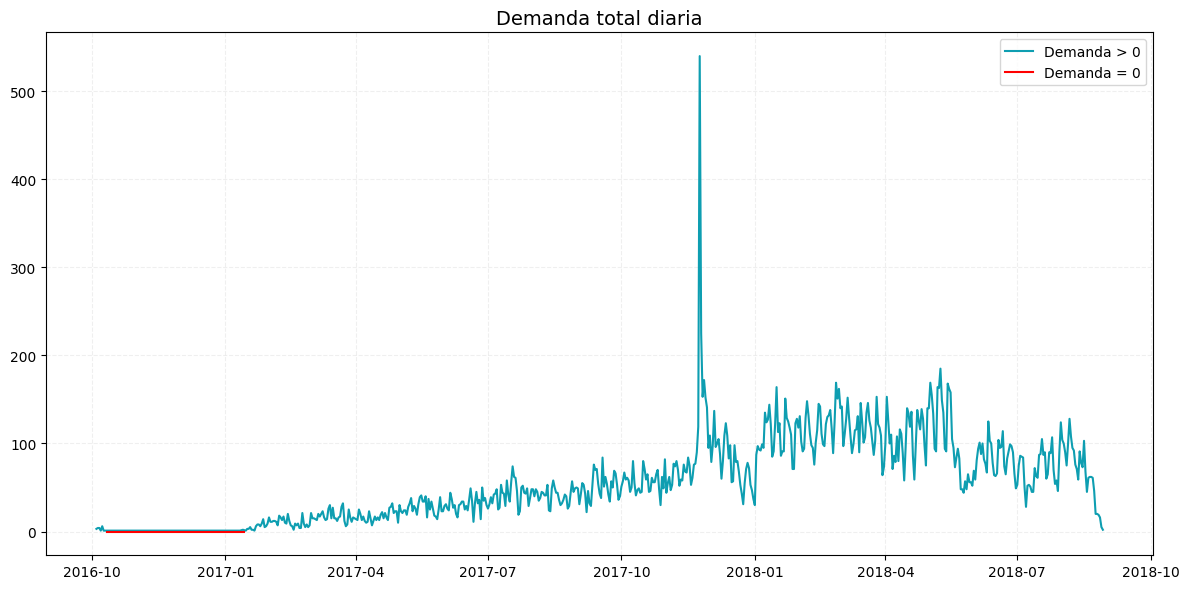

In [ ]:
# Graficar la demanda diaria
plt.figure(figsize=(12, 6))

daily_df_graph_positive = daily_df_graph[daily_df_graph['product_count'] > 0]
daily_df_graph_zero = daily_df_graph[daily_df_graph['product_count'] == 0]

sns.lineplot(x='date', y='product_count', data=daily_df_graph_positive, color='#0E9EB1', label='Demanda > 0')
sns.lineplot(x='date', y='product_count', data=daily_df_graph_zero, color='red', label='Demanda = 0')

plt.title('Demanda total diaria', fontsize=14)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

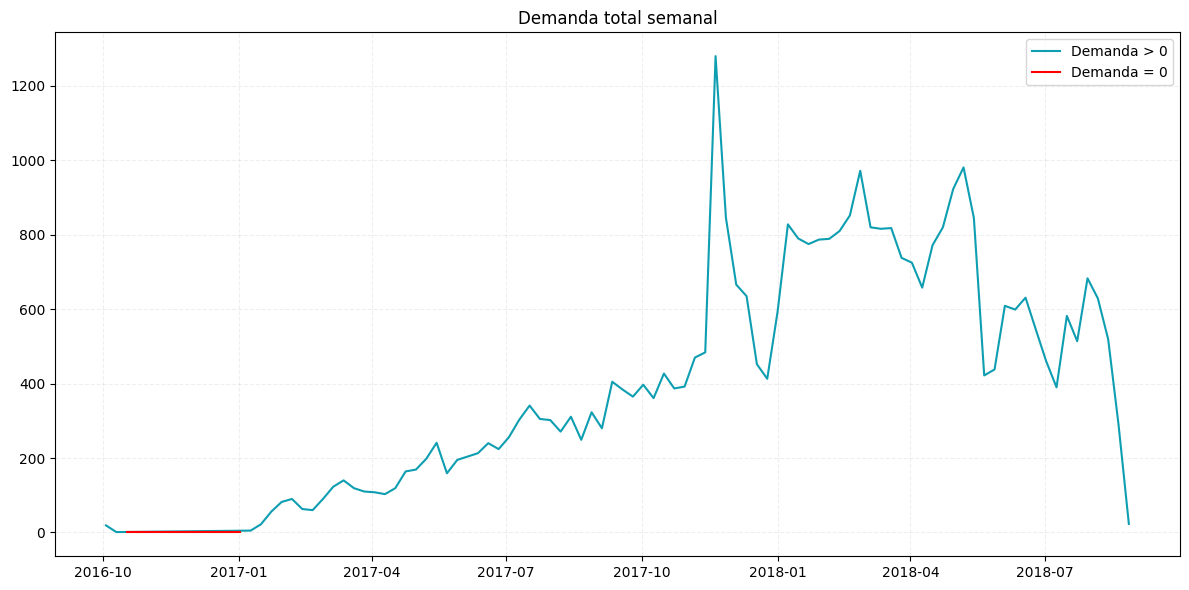

In [ ]:
# Graficar la demanda semanal
plt.figure(figsize=(12, 6))

weekly_df_graph_positive = weekly_df_graph[weekly_df_graph['product_count'] > 0]
weekly_df_graph_zero = weekly_df_graph[weekly_df_graph['product_count'] == 0]

sns.lineplot(x='week_of_year_name', y='product_count', data=weekly_df_graph_positive, color='#0E9EB1', label='Demanda > 0')
sns.lineplot(x='week_of_year_name', y='product_count', data=weekly_df_graph_zero, color='red', label='Demanda = 0')

plt.title('Demanda total semanal')
plt.xlabel('')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

En 2016 hubo sólo unas ventas aisladas. Se eliminan para mejorar el rendimiento de los modelos.

El primer día con ventas después de 2016 es el 10/01/2017 (martes), que corresponde a la semana del lunes 09/01/2017. Por tanto, como para la reconciliación temporal diaria-semanal debe coincidir la fecha inicial en ambos casos y además debe ser lunes para tener datos de la semana completa, se elige como fecha de inicio el 09/01/2017.

Los últimos días hay una caída abrupta de demanda, que se deduce que es artificial más adelante. Por tanto, como para la reconciliación temporal diaria-semanal debe coincidir la fecha final en ambos casos y además debe ser domingo para tener datos de la semana completa, se fija como fecha final 19/08/2018, que es el último domingo antes de la caída artificial.


In [ ]:
# Establecer umbrales
start_date = '2017-01-09' # Lunes
end_date = '2018-08-19' # Domingo
future_predicts_start_date = '2018-08-20' # Lunes
future_predicts_end_date = '2018-09-02' # Domingo

# Filtrar tabla
df_filtrado_3 = df_filtrado_2[(df_filtrado_2['order_purchase_date'] >= start_date) & (df_filtrado_2['order_purchase_date'] <= end_date)]
df_filtrado_final = df_filtrado_3

In [ ]:
# Imprimir resumen
print("Antes del filtrado de fecha inicial-final:")
print(f"Fecha inicial de las series temporales: {min_date.date()}")
print(f"Fecha final de las series temporales: {max_date.date()}")
print(f"Total de días: {(max_date - min_date).days}")
print(f"Total de semanas: {int(np.floor((max_date - min_date).days / 7))}")
print(f"Total de productos distintos: {df_filtrado_2['product_id'].nunique()}")
print(f"Total de categorías distintas: {df_filtrado_2['product_category_name'].nunique()}")
print(f"Total de ventas: {df_filtrado_2.shape[0]}")

print("\nDespués del filtrado de fecha inicial-final:")
start_date_dt = pd.to_datetime(start_date)
end_date_dt = pd.to_datetime(end_date)
print(f"Fecha inicial de las series temporales: {start_date_dt.date()}")
print(f"Fecha final de las series temporales: {end_date_dt.date()}")
print(f"Total de días: {(end_date_dt - start_date_dt).days}")
print(f"Total de semanas: {int(np.floor((end_date_dt - start_date_dt).days / 7))}")
print(f"Total de productos distintos: {df_filtrado_final['product_id'].nunique()}")
print(f"Total de categorías distintas: {df_filtrado_final['product_category_name'].nunique()}")
print(f"Total de ventas: {df_filtrado_final.shape[0]}")

Antes del filtrado de fecha inicial-final:
Fecha inicial de las series temporales: 2016-10-04
Fecha final de las series temporales: 2018-08-29
Total de días: 694
Total de semanas: 99
Total de productos distintos: 1189
Total de categorías distintas: 55
Total de ventas: 38068

Después del filtrado de fecha inicial-final:
Fecha inicial de las series temporales: 2017-01-09
Fecha final de las series temporales: 2018-08-19
Total de días: 587
Total de semanas: 83
Total de productos distintos: 1189
Total de categorías distintas: 55
Total de ventas: 37735


In [ ]:
# Descargar dataframe
df_filtrado_final.to_csv(os.path.join(ruta_output, 'df_filtrado_final.csv'), index=False, sep=';', decimal=',')

A continuación, se comprueba el motivo de la caída final en demanda

In [ ]:
# Crear dataframe auxiliar
orders_df2 = orders_df
orders_df2['order_purchase_timestamp'] = pd.to_datetime(orders_df2['order_purchase_timestamp'])
orders_df2['order_purchase_date'] = orders_df2['order_purchase_timestamp'].dt.date
orders_df2['order_purchase_date'] = pd.to_datetime(orders_df2['order_purchase_date'])
orders_df2['order_purchase_year_month'] = orders_df2['order_purchase_timestamp'].dt.to_period('M')

# Cruce con la tabla calendario
orders_df2 = orders_df2.merge(cal_df, left_on='order_purchase_date', right_on='date', how='left')

# Imprimir dataframe
# display(orders_df2)

In [ ]:
# Crear tabla auxiliar de un group by de la semana y un pivot del estatus del pedido
grouped_df = orders_df2.groupby(['week_of_year_name', 'order_status']).size().reset_index(name='count')
pivoted_df = grouped_df.pivot(index='week_of_year_name', columns='order_status', values='count').fillna(0).astype(int)

# Orden deseado de las categorías 'order_status'
orden_status = ['canceled', 'unavailable', 'delivered', 'shipped', 'processing', 'invoiced', 'approved', 'created']

# Imputar 0 a los nulos
pivoted_df = pivoted_df.reindex(columns=orden_status, fill_value=0)

# Imprimir tabla
print('Comprobación del estatus de los pedidos a nivel semanal')
display(pivoted_df.tail(20))

Comprobación del estatus de los pedidos a nivel semanal


order_status,canceled,unavailable,delivered,shipped,processing,invoiced,approved,created
week_of_year_name,,,,,,,,
2018-05-28,1,1,1075,5,0,1,0,0
2018-06-04,5,0,1422,11,0,0,0,0
2018-06-11,2,0,1497,14,0,1,0,0
2018-06-18,6,0,1443,7,0,1,0,0
2018-06-25,5,3,1382,11,0,0,0,0
2018-07-02,8,0,1178,10,0,0,0,0
2018-07-09,7,6,972,13,0,3,0,0
2018-07-16,10,2,1649,14,0,3,0,0
2018-07-23,8,4,1610,18,1,5,0,0


In [ ]:
# Crear tabla auxiliar de un group by del día y un pivot del estatus del pedido
grouped_df = orders_df2.groupby(['date', 'order_status']).size().reset_index(name='count')
pivoted_df = grouped_df.pivot(index='date', columns='order_status', values='count').fillna(0).astype(int)

# Orden deseado de las categorías 'order_status'
orden_status = ['canceled', 'unavailable', 'delivered', 'shipped', 'processing', 'invoiced', 'approved', 'created']

# Imputar 0 a los nulos
pivoted_df = pivoted_df.reindex(columns=orden_status, fill_value=0)

# Imprimir tabla
print('Comprobación del estatus de los pedidos a nivel diario')
display(pivoted_df.tail(50))

Comprobación del estatus de los pedidos a nivel diario


order_status,canceled,unavailable,delivered,shipped,processing,invoiced,approved,created
date,,,,,,,,
2018-07-28,0,1,172,2,0,1,0,0
2018-07-29,4,0,182,2,0,0,0,0
2018-07-30,4,4,278,2,0,0,0,0
2018-07-31,4,2,313,1,0,2,0,0
2018-08-01,2,1,306,2,0,0,0,0
2018-08-02,2,2,292,3,0,3,0,0
2018-08-03,2,0,308,1,0,3,0,0
2018-08-04,3,0,236,5,0,1,0,0
2018-08-05,2,0,269,2,0,3,0,0


## **3. EDA - Parte 1**

### **3.1. Gráfico de barras de la categoría de producto**

In [ ]:
# Obtener número de valores distintos de la columna 'product_category_name'
print('Nº de valores únicos de product_category_name: ', df_filtrado_final['product_category_name'].nunique())

Nº de valores únicos de product_category_name:  55


In [ ]:
# Obtener conteo de productos distintos por categoría de producto
category_product_counts = df_filtrado_final.groupby('product_category_name').agg(
    # product_id_count=('product_id', 'count'),
    product_id_nunique=('product_id', 'nunique')
).reset_index()

# Ordenar de forma descendente
category_product_counts = category_product_counts.sort_values(by='product_id_nunique', ascending=False)

# Imprimir resultados
# display(category_product_counts.head())

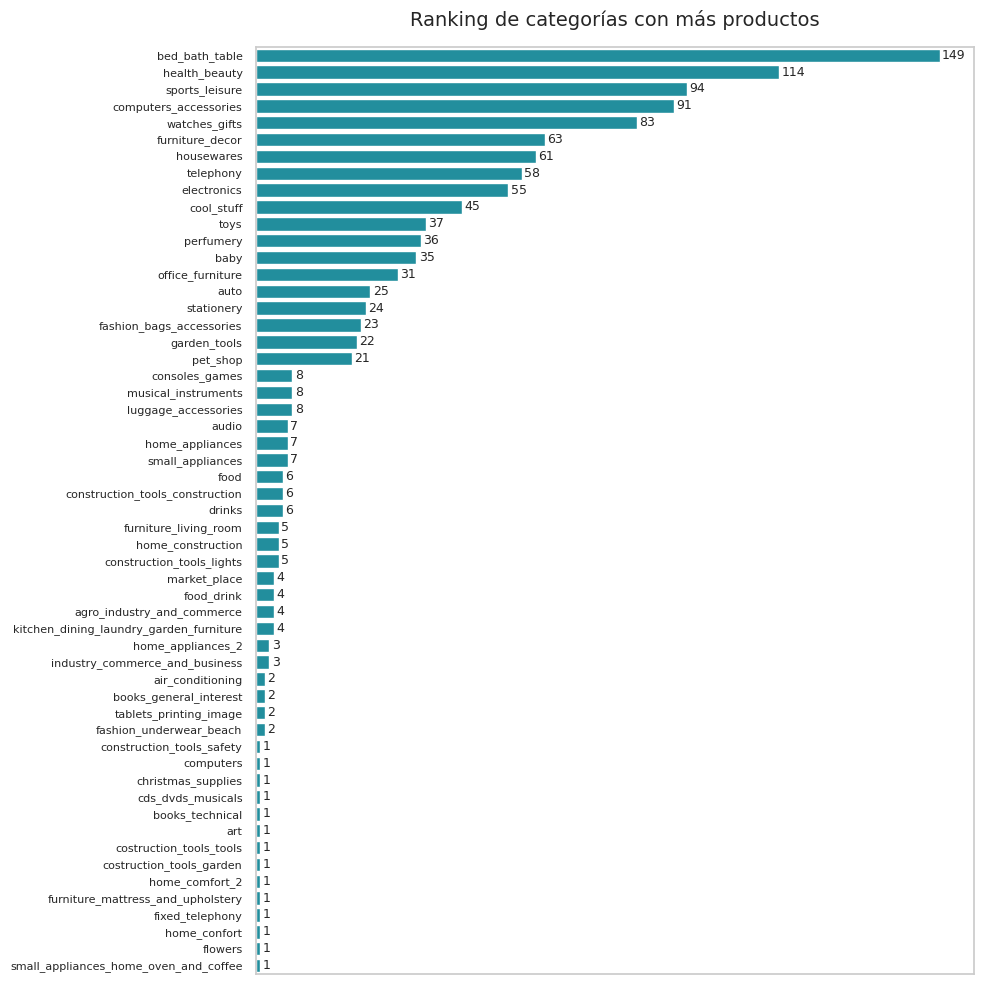

In [ ]:
# Realizar el gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 10))

ax = sns.barplot(
    y='product_category_name',
    x='product_id_nunique',
    data=category_product_counts,
    color='#0E9EB1'
)

# Añadir etiquetas de valor a las barras
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height() / 2,
             '{:1.0f}'.format(width),
             ha='left', va='center', fontsize=9)

plt.title('Ranking de categorías con más productos', fontsize=14, pad=15)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
ax.tick_params(axis='y', labelsize=8)

ax.set_xticks([]) # Ocultar las marcas del eje x
ax.set_xlabel('') # Ocultar la etiqueta del eje x

plt.tight_layout()
plt.show()

### **3.2. Gráfico de Pareto**

In [ ]:
# Crear dataframe auxiliar agrupando por 'product_id' y 'product_category_name'
product_stats_df_filt = df_filtrado_final.groupby(['product_id', 'product_category_name']).agg(
    distinct_order_ids=('order_id', 'nunique'),
    distinct_purchase_dates=('order_purchase_date', 'nunique'),
    max_purchase_date=('order_purchase_date', 'max'),
    distinct_purchase_weeks=('week_of_year_name', 'nunique'),
    max_purchase_week=('week_of_year_name', 'max'),
    count=('product_id', 'size')
).reset_index()

# Calcular columnas
total_products_in_cleaned_df = df_filtrado_final.shape[0]
product_stats_df_filt['relative_count'] = (product_stats_df_filt['count'] / total_products_in_cleaned_df) * 100

# Ordenar dataframe
product_stats_df_filt = product_stats_df_filt.sort_values(by='count', ascending=False)

# Calcular columnas
product_stats_df_filt['cumulative_relative_count'] = product_stats_df_filt['relative_count'].cumsum()
product_stats_df_filt['rank'] = range(1, len(product_stats_df_filt) + 1)
product_stats_df_filt['cumulative_relative_products'] = (product_stats_df_filt['rank'] / len(product_stats_df_filt)) * 100

# Imprimir dataframe
display(product_stats_df_filt)

,product_id,product_category_name,distinct_order_ids,distinct_purchase_dates,max_purchase_date,distinct_purchase_weeks,max_purchase_week,count,relative_count,cumulative_relative_count,rank,cumulative_relative_products
816,aca2eb7d00ea1a7b8ebd4e68314663af,furniture_decor,425,171,2018-08-18,38,2018-08-13,520,1.378031,1.378031,1,0.084104
300,422879e10f46682990de24d770e7f83d,garden_tools,352,196,2018-08-14,58,2018-08-13,484,1.282629,2.660660,2,0.168209
717,99a4788cb24856965c36a24e339b6058,bed_bath_table,456,263,2018-08-19,74,2018-08-13,477,1.264078,3.924738,3,0.252313
264,389d119b48cf3043d311335e499d9c6b,garden_tools,309,189,2018-08-16,60,2018-08-13,390,1.033523,4.958262,4,0.336417
252,368c6c730842d78016ad823897a372db,garden_tools,290,177,2018-08-16,56,2018-08-13,387,1.025573,5.983835,5,0.420521
...,...,...,...,...,...,...,...,...,...,...,...,...
181,27a7e832bcfcd69ff687d611c3e79cbd,perfumery,10,10,2018-05-18,8,2018-05-14,10,0.026501,99.907248,1185,99.663583
1035,dfec64aac9b864b2807a7be33222b75f,bed_bath_table,9,9,2018-05-11,8,2018-05-07,9,0.023851,99.931098,1186,99.747687
423,5a0c21ad6b82a1b61856e48ec959764d,perfumery,9,9,2018-08-08,9,2018-08-06,9,0.023851,99.954949,1187,99.831791
454,5f0bdec2fb222061ed8fe52586a5957d,telephony,9,9,2018-03-09,9,2018-03-05,9,0.023851,99.978800,1188,99.915896


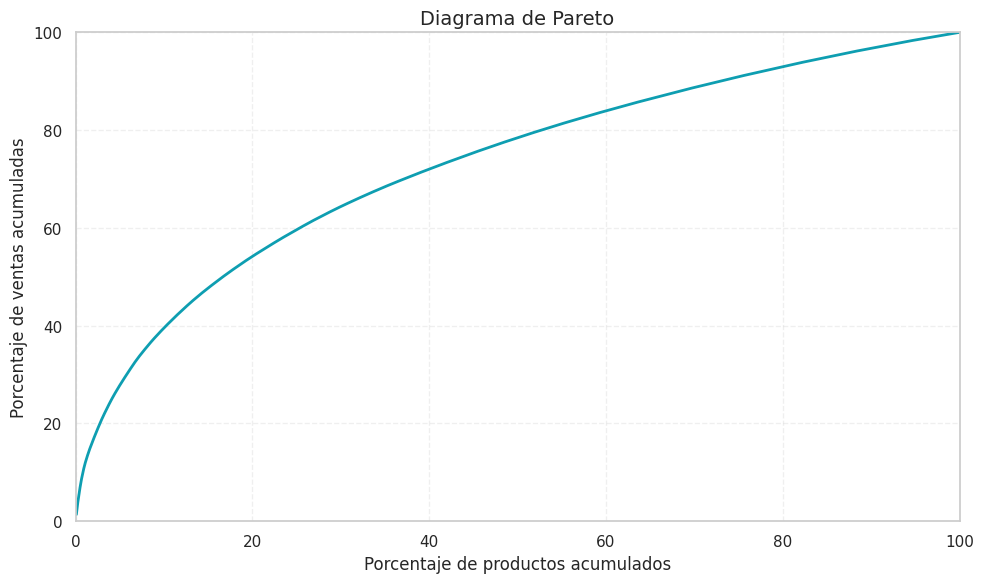

In [ ]:
# Realizar gráfico
plt.figure(figsize=(10, 6))
sns.lineplot(x='cumulative_relative_products', y='cumulative_relative_count', data=product_stats_df_filt, linewidth=2, color='#0E9EB1')

plt.xlabel('Porcentaje de productos acumulados', fontsize=12)
plt.ylabel('Porcentaje de ventas acumuladas', fontsize=12)
plt.title('Diagrama de Pareto', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [ ]:
# Imprimir resumen
print("Antes del filtrado")
print(f"Total de productos: {product_stats_df.shape[0]}, Total de ventas: {df_cruce_limpio.shape[0]}")
print("\nDespués del filtrado")
print(f"Total de productos: {product_stats_df_filt.shape[0]}, Total de ventas: {df_filtrado_final.shape[0]}")
print(f"Nos quedamos con el {round(product_stats_df_filt.shape[0]/product_stats_df.shape[0]*100,2)}% de los productos, que suponen el {round(df_filtrado_final.shape[0]/df_cruce_limpio.shape[0]*100,2)}% de las ventas totales")

Antes del filtrado
Total de productos: 31614, Total de ventas: 108621

Después del filtrado
Total de productos: 1189, Total de ventas: 37735
Nos quedamos con el 3.76% de los productos, que suponen el 34.74% de las ventas totales


In [ ]:
# Descargar dataframe
product_stats_df_filt.to_csv(os.path.join(ruta_output, 'product_stats_df_filt.csv'), index=False, sep=';', decimal=',')

## **4. Preprocesamiento e ingeniería de variables**

In [ ]:
# Obtener número de productos distintos tras el filtrado
productos_validos_2 = df_filtrado_final['product_id'].reset_index(drop=True).unique()
print('Nº de productos válidos: ', len(productos_validos_2))

Nº de productos válidos:  1189


In [ ]:
# Filtrar la tabla de calendario por las fechas de inicio y fin escogidas
cal_df_filtrado_2 = cal_df[(cal_df['date'] >= start_date) & (cal_df['date'] <= end_date)][['date', 'week_of_year_name']]

# Crear tabla con las fechas diarias
daily_df_cal = cal_df_filtrado_2['date'].reset_index(drop=True).unique()

# Crear tabla con las fechas semanales
weekly_df_cal = cal_df_filtrado_2['week_of_year_name'].drop_duplicates().reset_index(drop=True).unique()

In [ ]:
# Seleccionar las variables deseadas
seleccion_columnas = [
'product_id',
'order_purchase_date',
'price',
'product_category_name',
'product_name_lenght',
'product_description_lenght',
'product_photos_qty',
'product_weight_g',
'product_length_cm',
'product_height_cm',
'product_width_cm',
'day_of_week_name',
'day_of_week',
'cos_dow',
'sin_dow',
'day_of_year',
'cos_doy',
'sin_doy',
'week_of_year_name',
'week_of_year',
'cos_woy',
'sin_woy',
'is_weekend',
'is_month_start',
'is_month_end',
'is_national_holiday',
'is_black_friday']

df_preprocesamiento = df_filtrado_final[seleccion_columnas]

#### **4.1. Variables comunes**

##### **4.1.1. Variables de Order_Items**

In [ ]:
# Crear dataframe auxiliar con información de la variable precio por cada producto
order_items_stats = df_preprocesamiento.groupby('product_id').agg(
    demand=('product_id', 'size'),
    count_distinct_price=('price', 'nunique'),
    min_price=('price', 'min'),
    q1_price=('price', lambda x: x.quantile(0.25)),
    q2_price=('price', lambda x: x.quantile(0.5)),
    q3_price=('price', lambda x: x.quantile(0.75)),
    max_price=('price', 'max'),
    mean_price=('price', 'mean'),
    std_price=('price', 'std')
).reset_index()

# Añadir el coeficiente de variación
order_items_stats['CV_price'] = order_items_stats['std_price'] / order_items_stats['mean_price']

# Ordenar dataframe
order_items_stats = order_items_stats.sort_values(by='count_distinct_price', ascending=False)

# Imprimir dataframe
display(order_items_stats)

,product_id,demand,count_distinct_price,min_price,q1_price,q2_price,q3_price,max_price,mean_price,std_price,CV_price
314,437c05a395e9e47f9762e677a7068ce7,151,31,44.98,47.65,49.90,52.095,59.90,50.013709,2.785700,0.055699
990,d285360f29ac7fd97640bf0baef03de0,119,29,154.91,155.97,260.00,344.345,349.99,256.923613,77.467987,0.301521
1040,e0d64dcfaa3b6db5c54ca298ae101d05,192,27,124.90,145.00,155.00,179.900,255.61,163.936510,30.299871,0.184827
490,656e0eca68dcecf6a31b8ececfabe3e8,134,23,65.00,84.00,89.79,97.790,109.90,88.890373,11.563033,0.130082
530,6f3b5b605d91b7439c5e3f5a8dffeea7,113,21,128.90,145.00,156.00,165.000,239.90,162.642478,25.688292,0.157943
...,...,...,...,...,...,...,...,...,...,...,...
28,0705b33fb285827a578fce4899f1b921,29,1,22.50,22.50,22.50,22.500,22.50,22.500000,0.000000,0.000000
31,07a949f27854f64558f8babcfec441cc,13,1,39.90,39.90,39.90,39.900,39.90,39.900000,0.000000,0.000000
1157,f89d2b130b571d24532514dca6fee2a8,12,1,13.65,13.65,13.65,13.650,13.65,13.650000,0.000000,0.000000
1158,f8b624d4e475bb8d1bddf1b65c6a64f6,39,1,179.00,179.00,179.00,179.000,179.00,179.000000,0.000000,0.000000


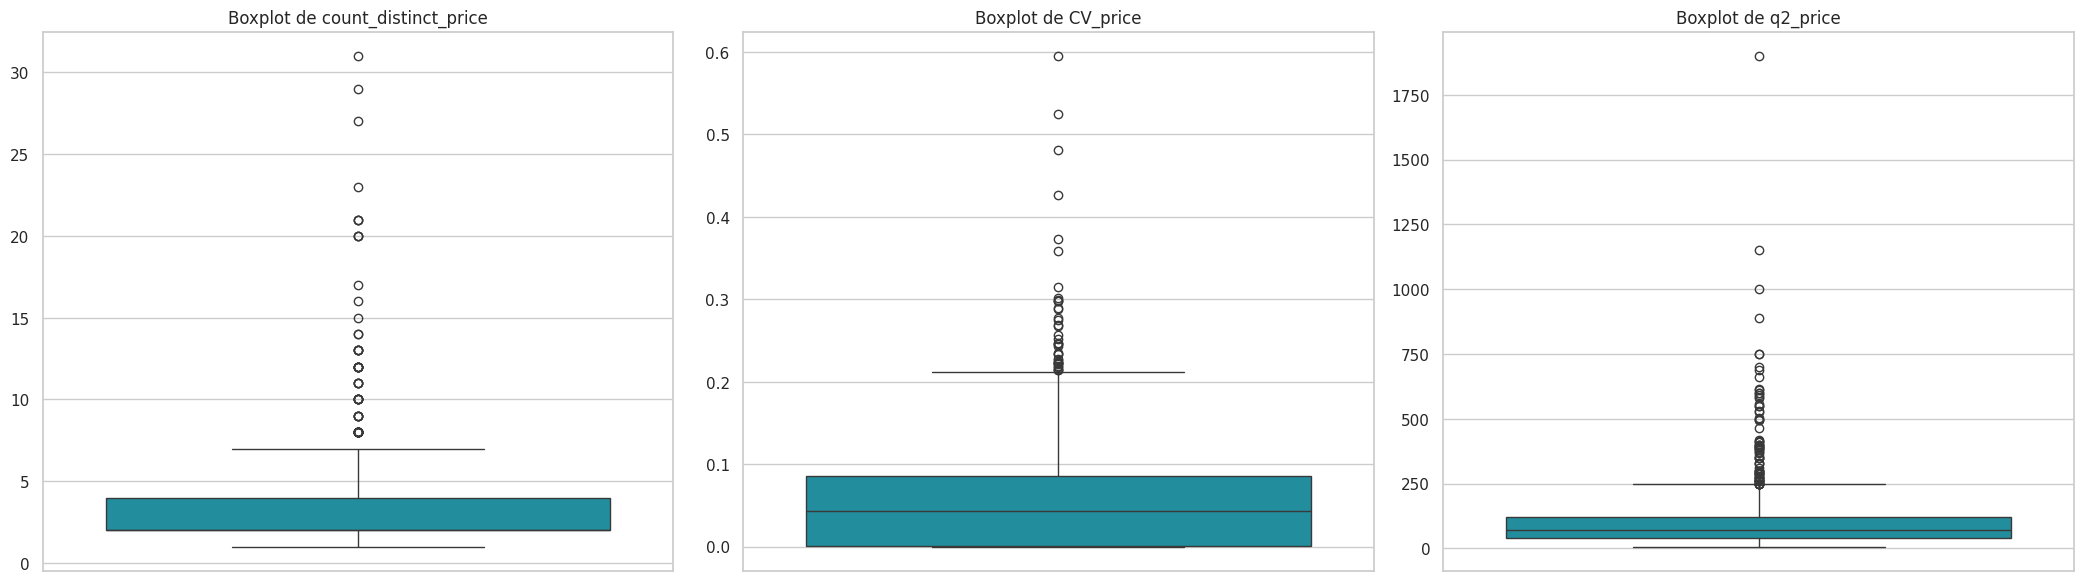

In [ ]:
# Crear una figura con tres gráficos
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Boxplot para count_distinct_price
sns.boxplot(y=order_items_stats['count_distinct_price'], ax=axes[0], color='#0E9EB1')
axes[0].set_title('Boxplot de count_distinct_price')
axes[0].set_ylabel('')

# Boxplot para CV
sns.boxplot(y=order_items_stats['CV_price'], ax=axes[1], color='#0E9EB1')
axes[1].set_title('Boxplot de CV_price')
axes[1].set_ylabel('')

# Boxplot para q2_price
sns.boxplot(y=order_items_stats['q2_price'], ax=axes[2], color='#0E9EB1')
axes[2].set_title('Boxplot de q2_price')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

In [ ]:
# Calcular correlaciones
correlation_pearson = order_items_stats['demand'].corr(order_items_stats['q2_price'], method='pearson')
correlation_spearman = order_items_stats['demand'].corr(order_items_stats['q2_price'], method='spearman')
print(f"La correlación de Pearson entre 'demand' y 'count_distinct_price' es: {correlation_pearson:.4f}")
print(f"La correlación de Spearman entre 'demand' y 'count_distinct_price' es: {correlation_spearman:.4f}")

La correlación de Pearson entre 'demand' y 'count_distinct_price' es: -0.0330
La correlación de Spearman entre 'demand' y 'count_distinct_price' es: 0.0045


En general, según el número de precios distintos y el CV por producto, el precio por producto varía poco. No es una variable altamente dinámica, sino que es un atributo bastante estable a lo largo del tiempo.

Teniendo esto en cuenta, y sumado a que en la serie diaria y semanal tenemos una alta intermitencia (días/semanas sin ventas, es decir, con demanda = 0) donde no hay un precio observado real, incorporamos el precio como una variable estática con la mediana del precio.

Además no podemos conocer el precio futuro cuando vayamos a predecir, porque es elección de los vendedores.

In [ ]:
# Aplicar un escalado robusto a la nueva variable de precio mediano
robust_scaler = RobustScaler()
order_items_stats['q2_price_esc'] = robust_scaler.fit_transform(order_items_stats[['q2_price']])

##### **4.1.2. Variables de Products**

In [ ]:
# Filtrar tabla por los productos válidos
products_df_filtrado = products_df[products_df['product_id'].isin(productos_validos_2)].copy()

In [ ]:
# Calcular la nueva variable de volumen
products_df_filtrado['product_volume'] = products_df_filtrado['product_length_cm'] * \
                                 products_df_filtrado['product_height_cm'] * \
                                 products_df_filtrado['product_width_cm']

# Renombrar la columna product_weight_g
products_df_filtrado = products_df_filtrado.rename(columns={'product_weight_g': 'product_weight'})

In [ ]:
# Obtener estadísticos de las variables cuantitativas
products_df_filtrado.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight,product_length_cm,product_height_cm,product_width_cm,product_volume
count,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000
mean,49.386880,813.756098,2.293524,2074.153911,29.555088,15.831791,22.945332,14171.634146
std,9.827812,676.560335,1.783425,3630.031500,15.957267,13.962261,11.911339,21042.387441
min,14.000000,49.000000,1.000000,50.000000,11.000000,2.000000,11.000000,352.000000
25%,43.000000,368.000000,1.000000,250.000000,18.000000,7.000000,15.000000,2574.000000
50%,52.000000,626.000000,1.000000,600.000000,24.000000,12.000000,20.000000,5566.000000
75%,57.000000,1003.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,15840.000000
max,64.000000,3902.000000,10.000000,30000.000000,105.000000,105.000000,100.000000,210000.000000


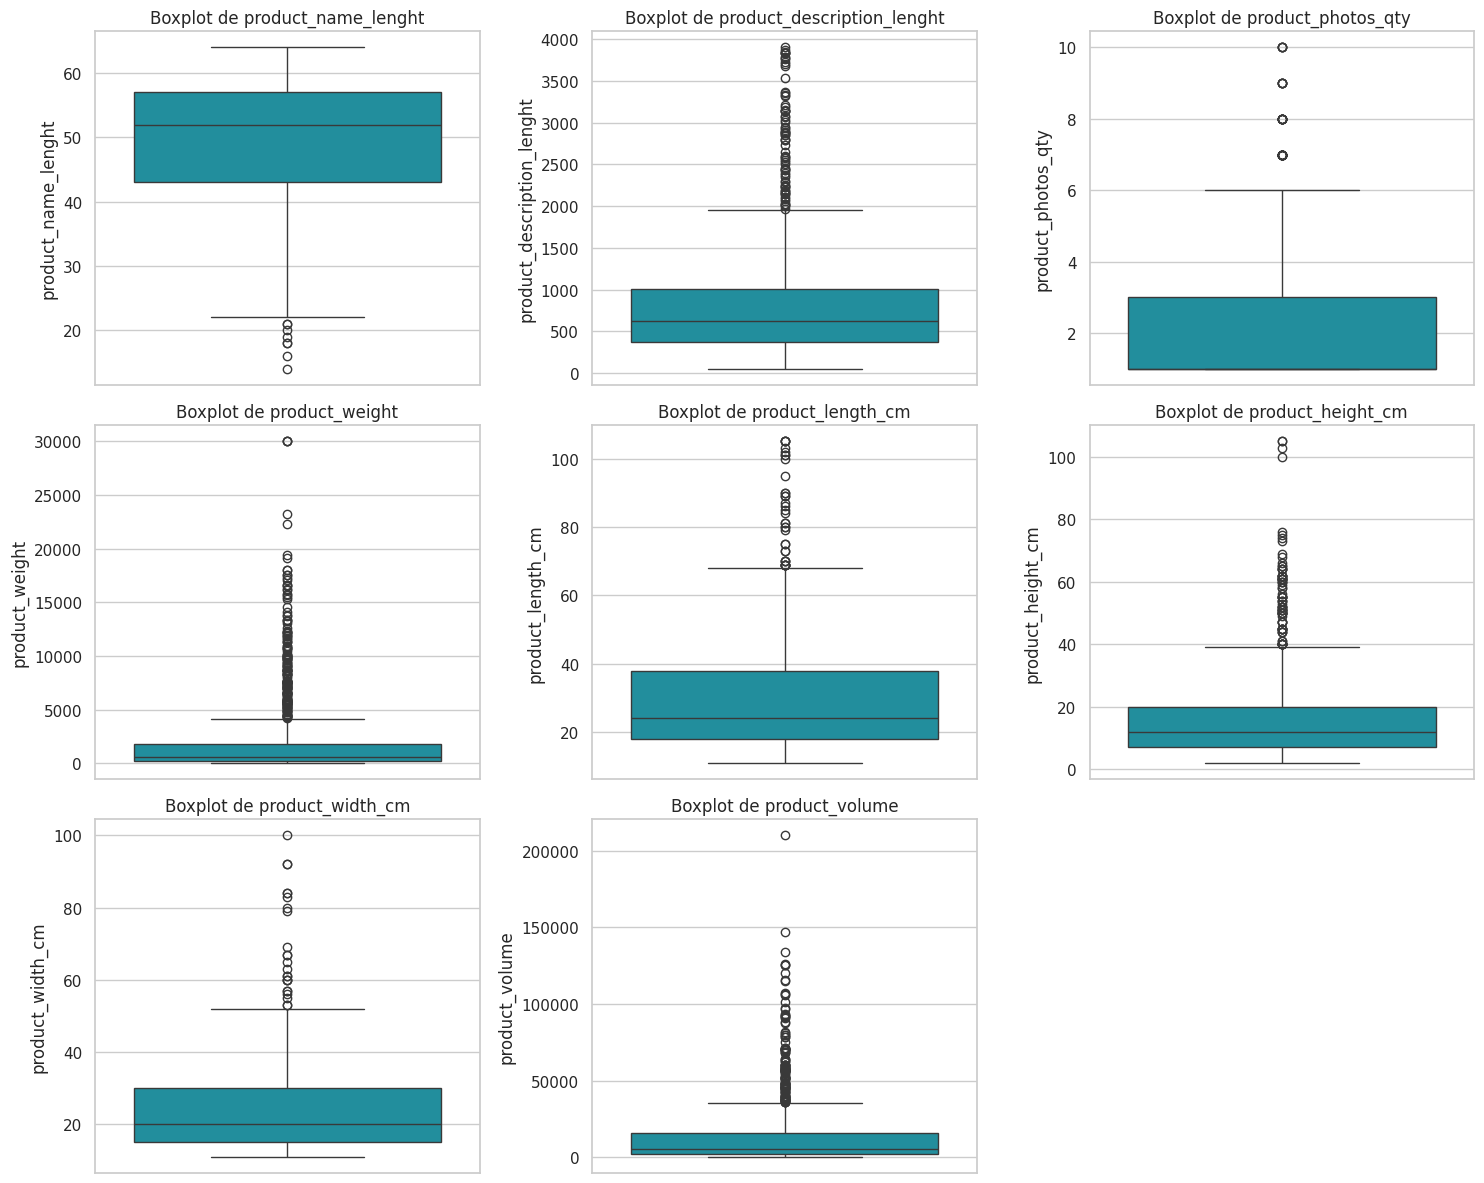

In [ ]:
# Indicar variables cuantitativas
numerical_cols = products_df_filtrado.select_dtypes(include=np.number).columns

# Realizar gráficos
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols # Calcular filas necesarias

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=products_df_filtrado[col], ax=axes[i], color='#0E9EB1')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Inicializar escaladores
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Definir variables para cada escalador
minmax_cols = ['product_name_lenght', 'product_photos_qty']
robust_cols = ['product_description_lenght', 'product_volume', 'product_weight']

# Aplicar MinMaxScaler y añadir sufijo '_esc'
products_df_filtrado[[f'{col}_esc' for col in minmax_cols]] = minmax_scaler.fit_transform(products_df_filtrado[minmax_cols])

# Aplicar RobustScaler y añadir sufijo '_esc'
products_df_filtrado[[f'{col}_esc' for col in robust_cols]] = robust_scaler.fit_transform(products_df_filtrado[robust_cols])

# Mostrar el resultado de las nuevas columnas
display(products_df_filtrado)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight,product_length_cm,product_height_cm,product_width_cm,product_volume,product_name_lenght_esc,product_photos_qty_esc,product_description_lenght_esc,product_volume_esc,product_weight_esc
46,5f504b3a1c75b73d6151be81eb05bdc9,cool_stuff,38.0,1176.0,3.0,15350.0,47.0,40.0,47.0,88360.0,0.48,0.222222,0.866142,6.241067,9.516129
92,adf591c625cb265c12bc6749d3a2f757,health_beauty,60.0,1146.0,6.0,150.0,20.0,24.0,33.0,15840.0,0.92,0.555556,0.818898,0.774461,-0.290323
151,dd768d259ee6054e0dadd66c8e2be0b6,bed_bath_table,52.0,700.0,2.0,350.0,16.0,10.0,16.0,2560.0,0.76,0.111111,0.116535,-0.226594,-0.161290
175,4473f3e5c65952b074ef987fa5c24662,telephony,59.0,776.0,6.0,350.0,17.0,4.0,12.0,816.0,0.90,0.555556,0.236220,-0.358058,-0.161290
194,5e21d5cab5d33e770d8150a4ee6117db,watches_gifts,60.0,312.0,4.0,200.0,16.0,2.0,11.0,352.0,0.92,0.333333,-0.494488,-0.393035,-0.258065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32865,00faa46f36261af8bbf3a4d37fa4841b,fashion_bags_accessories,49.0,293.0,1.0,100.0,21.0,9.0,14.0,2646.0,0.70,0.000000,-0.524409,-0.220112,-0.322581
32905,70bf4f61950297cf24e18a9b84c3208a,housewares,59.0,203.0,1.0,400.0,16.0,10.0,14.0,2240.0,0.90,0.000000,-0.666142,-0.250716,-0.129032
32923,7088744b00831b410bd17716cb578f39,computers_accessories,51.0,311.0,1.0,1013.0,30.0,15.0,16.0,7200.0,0.74,0.000000,-0.496063,0.123172,0.266452
32940,dfec64aac9b864b2807a7be33222b75f,bed_bath_table,58.0,252.0,4.0,850.0,38.0,7.0,28.0,7448.0,0.88,0.333333,-0.588976,0.141866,0.161290


In [ ]:
# Indicar variables cuantitativas
numerical_cols = products_df_filtrado.select_dtypes(include=np.number).columns

# Obtener estadísticos de las variables cuantitativas escaladas
scaled_cols = [col for col in numerical_cols if col.endswith('_esc')]
products_df_filtrado[scaled_cols].describe()

,product_name_lenght_esc,product_photos_qty_esc,product_description_lenght_esc,product_volume_esc,product_weight_esc
count,1189.000000,1189.000000,1189.000000,1189.000000,1189.000000
mean,0.707738,0.143725,0.295679,0.648698,0.951067
std,0.196556,0.198158,1.065449,1.586189,2.341956
min,0.000000,0.000000,-0.908661,-0.393035,-0.354839
25%,0.580000,0.000000,-0.406299,-0.225539,-0.225806
50%,0.760000,0.000000,0.000000,0.000000,0.000000
75%,0.860000,0.222222,0.593701,0.774461,0.774194
max,1.000000,1.000000,5.159055,15.410372,18.967742


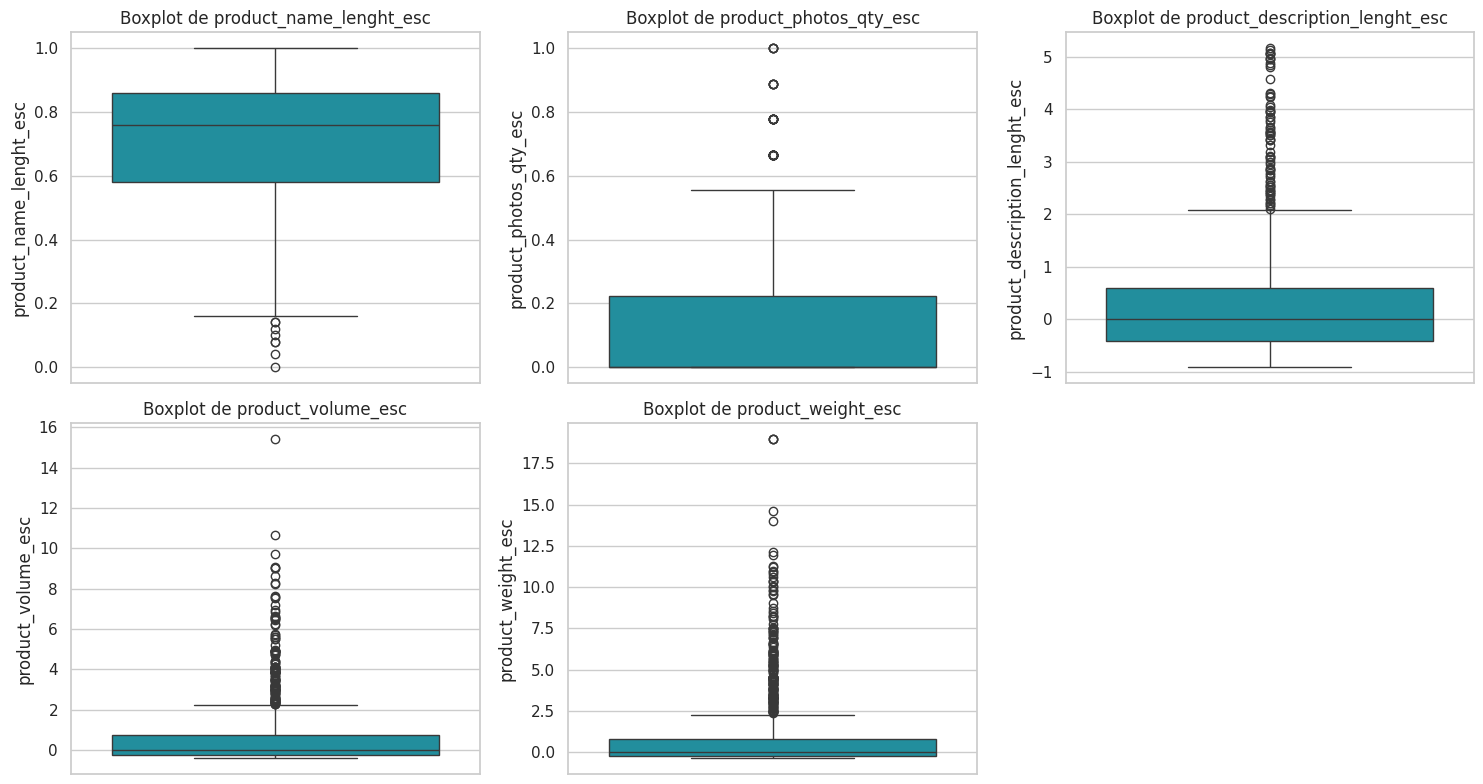

In [ ]:
# Realizar gráficos
n_cols = 3
n_rows = (len(scaled_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(scaled_cols):
    sns.boxplot(y=products_df_filtrado[col], ax=axes[i], color='#0E9EB1')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

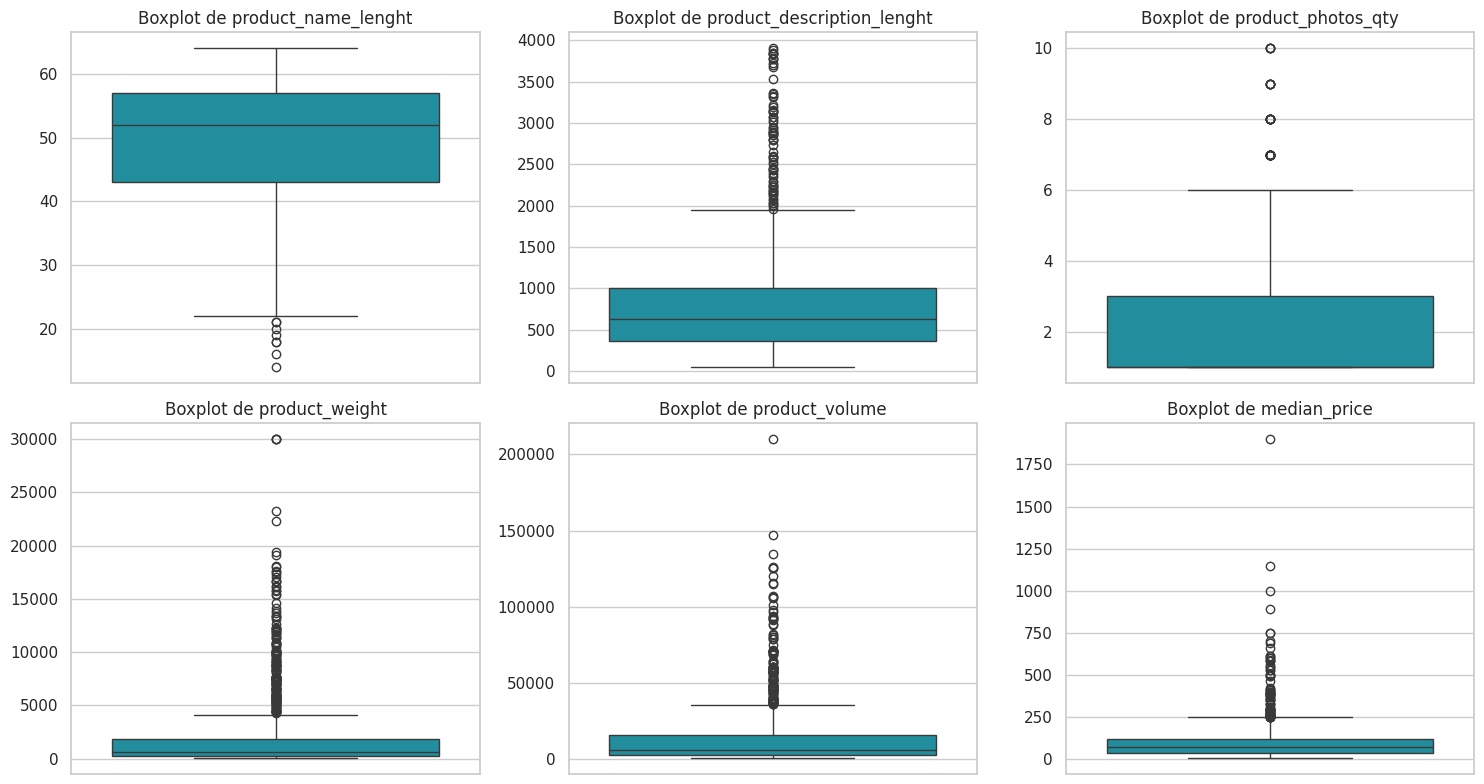

In [ ]:
# EXTRA
# Juntar en una misma figura los boxplots de las variables de Orders y los de las variables de Products antes de escalarlas

# Indicar las variables a graficar
numerical_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight',
    'product_volume',
    'q2_price'
]

# Realizar los gráficos
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if col == 'q2_price':
        sns.boxplot(y=order_items_stats[col], ax=axes[i], color='#0E9EB1')
        axes[i].set_title(f'Boxplot de median_price')
    else:
        sns.boxplot(y=products_df_filtrado[col], ax=axes[i], color='#0E9EB1')
        axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

####**4.2. Variables específicas: variables de calendario**

Se crean los dataframes que serán el input de los modelos con la estructura necesaria (formato long)

#### **4.2.1. Serie diaria**

In [ ]:
# Obtener todas las combinaciones de producto-día
grid_index_daily = pd.MultiIndex.from_product([productos_validos_2, daily_df_cal], names=['product_id', 'ds'])
daily_df = pd.DataFrame(index=grid_index_daily).reset_index()
daily_df['ds'] = pd.to_datetime(daily_df['ds'])

In [ ]:
# Crear dataframe auxiliar con la demanda de cada producto por día
daily_df_orders = df_filtrado_final.groupby(['product_id', 'order_purchase_date']).size().reset_index(name='demand')

In [ ]:
# Cruzar las tablas anteriores
daily_df2 = daily_df.merge(daily_df_orders[['product_id', 'order_purchase_date', 'demand']],
                      left_on=['product_id', 'ds'],
                      right_on=['product_id', 'order_purchase_date'],
                      how='left')

# Eliminar columnas innecesarias
daily_df2 = daily_df2.drop(columns=['order_purchase_date'])

# Imputar 0 a los valores nulos de la demanda (días sin ventas)
daily_df2['demand'] = daily_df2['demand'].fillna(0).astype(int)

# Imprimir tabla
display(daily_df2)

,product_id,ds,demand
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0
1,ac6c3623068f30de03045865e4e10089,2017-01-10,0
2,ac6c3623068f30de03045865e4e10089,2017-01-11,0
3,ac6c3623068f30de03045865e4e10089,2017-01-12,0
4,ac6c3623068f30de03045865e4e10089,2017-01-13,0
...,...,...,...
699127,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-15,0
699128,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-16,0
699129,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-17,0
699130,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-18,0


In [ ]:
# Calcular intermitencia del dataset (días con demanda nula)
freq_abs_cero = daily_df2[daily_df2['demand'] == 0].shape[0]
total_filas = daily_df2.shape[0]
freq_rel_cero = (freq_abs_cero / total_filas) * 100

print(f"Frecuencia absoluta del valor 0 en 'demand': {freq_abs_cero}")
print(f"Frecuencia relativa del valor 0 en 'demand': {freq_rel_cero:.2f}%")

Frecuencia absoluta del valor 0 en 'demand': 670238
Frecuencia relativa del valor 0 en 'demand': 95.87%


In [ ]:
# Realizar el left join con la tabla de Order_Items para traer las variables deseadas
daily_df3 = daily_df2.merge(order_items_stats,
                            left_on='product_id',
                            right_on='product_id',
                            how='left')

# Quedarse sólo con las columnas necesarias
daily_df3 = daily_df3[['product_id','ds','demand_x','q2_price_esc']]
daily_df3 = daily_df3.rename(columns={'demand_x': 'demand',
                                      'q2_price_esc': 'median_price_esc'})

In [ ]:
# Realizar el left join con tabla Products para traer las variables deseadas
daily_df3 = daily_df3.merge(products_df_filtrado,
                            left_on='product_id',
                            right_on='product_id',
                            how='left')

# Quedarse sólo con las columnas necesarias
daily_df3 = daily_df3[['product_id','ds','demand','product_category_name','product_name_lenght_esc','product_description_lenght_esc','product_photos_qty_esc','product_volume_esc','product_weight_esc','median_price_esc']]

In [ ]:
# Realizar el left join con tabla Calendario para traer las variables deseadas
daily_df3 = daily_df3.merge(cal_df,
                            left_on='ds',
                            right_on='date',
                            how='left')

# Quedarse sólo con las columnas necesarias
daily_df3 = daily_df3.drop(['date','day_of_week','week_of_year','week_of_year_name','sin_woy','cos_woy','day_of_year'], axis=1)

# Renombrar columnas de forma adecuada para modelos de Nixtla
daily_df3 = daily_df3.rename(columns={'product_id': 'unique_id', 'demand': 'y'})

# Imprimir dataset
display(daily_df3)

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,day_of_week_name,cos_dow,sin_dow,cos_doy,sin_doy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,Monday,1.000000,0.000000,0.988039,0.154204,0,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-10,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,Tuesday,0.623490,0.781831,0.985240,0.171177,0,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-11,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,Wednesday,-0.222521,0.974928,0.982150,0.188099,0,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-12,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,Thursday,-0.900969,0.433884,0.978769,0.204966,0,0,0,0,0
4,ac6c3623068f30de03045865e4e10089,2017-01-13,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,Friday,-0.900969,-0.433884,0.975099,0.221772,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699127,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-15,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,Wednesday,-0.222521,0.974928,-0.722519,-0.691351,0,0,0,0,0
699128,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-16,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,Thursday,-0.900969,0.433884,-0.710520,-0.703677,0,0,0,0,0
699129,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-17,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,Friday,-0.900969,-0.433884,-0.698310,-0.715795,0,0,0,0,0
699130,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-18,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,Saturday,-0.222521,-0.974928,-0.685894,-0.727701,1,0,0,0,0


##### **4.2.1.1. Gráfico correlaciones a nivel diario**

In [ ]:
# Obtener un dataframe auxiliar con la demanda a nivel de fecha
daily_df_graph_2 = daily_df_graph.merge(cal_df,
                                             left_on='date',
                                             right_on='date',
                                             how='left')

daily_df_graph_2 = daily_df_graph_2[(daily_df_graph_2['date'] >= start_date) & (daily_df_graph_2['date'] <= end_date)]

# Imprimir dataframe
display(daily_df_graph_2)

,date,product_count,day_of_week_name,day_of_week,cos_dow,sin_dow,day_of_year,cos_doy,sin_doy,week_of_year_name,week_of_year,cos_woy,sin_woy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
97,2017-01-09,0,Monday,1,1.000000,0.000000,9,0.988039,0.154204,2017-01-09,2,0.971138,0.238517,0,0,0,0,0
98,2017-01-10,1,Tuesday,2,0.623490,0.781831,10,0.985240,0.171177,2017-01-09,2,0.971138,0.238517,0,0,0,0,0
99,2017-01-11,1,Wednesday,3,-0.222521,0.974928,11,0.982150,0.188099,2017-01-09,2,0.971138,0.238517,0,0,0,0,0
100,2017-01-12,0,Thursday,4,-0.900969,0.433884,12,0.978769,0.204966,2017-01-09,2,0.971138,0.238517,0,0,0,0,0
101,2017-01-13,2,Friday,5,-0.900969,-0.433884,13,0.975099,0.221772,2017-01-09,2,0.971138,0.238517,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,2018-08-15,73,Wednesday,3,-0.222521,0.974928,227,-0.722519,-0.691351,2018-08-13,33,-0.673215,-0.739447,0,0,0,0,0
681,2018-08-16,103,Thursday,4,-0.900969,0.433884,228,-0.710520,-0.703677,2018-08-13,33,-0.673215,-0.739447,0,0,0,0,0
682,2018-08-17,68,Friday,5,-0.900969,-0.433884,229,-0.698310,-0.715795,2018-08-13,33,-0.673215,-0.739447,0,0,0,0,0
683,2018-08-18,45,Saturday,6,-0.222521,-0.974928,230,-0.685894,-0.727701,2018-08-13,33,-0.673215,-0.739447,1,0,0,0,0


Las medidas de asociación correctas entre pares de variables continua-binaria (biserial puntual) y binaria-binaria (coeficiente phi) son matemáticamente equivalentes a la correlación de Pearson en estos casos.

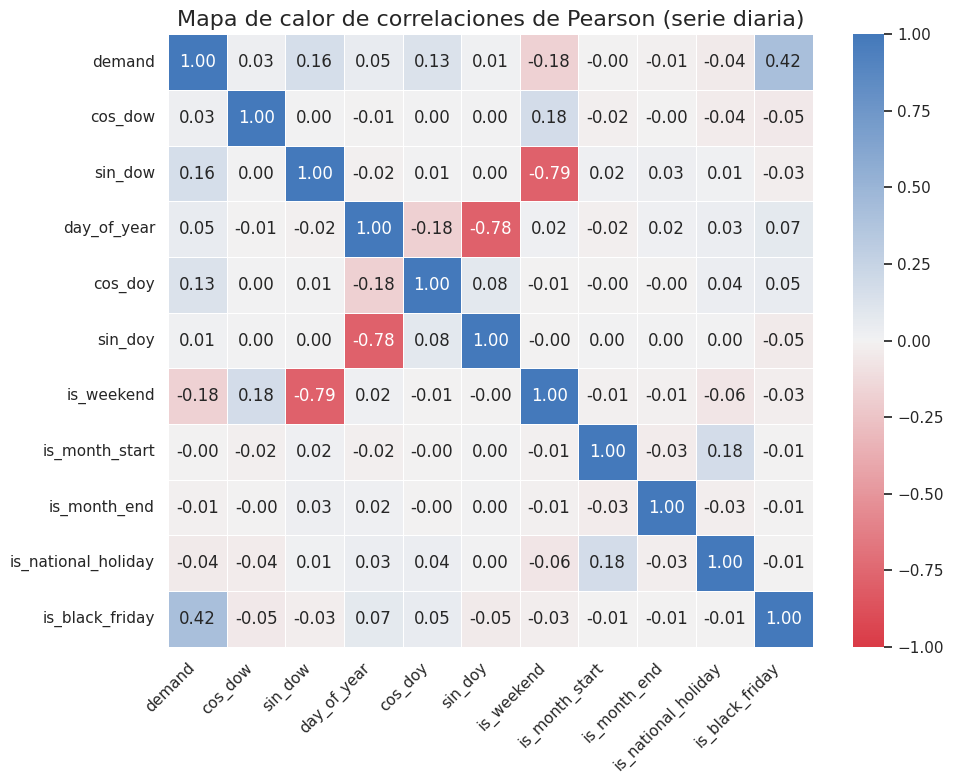

In [ ]:
# Renombrar la columna de demanda para el gráfico
daily_df_graph_2 = daily_df_graph_2.rename(columns={'product_count': 'demand'})
numerical_cols = daily_df_graph_2.select_dtypes(include=np.number).columns.drop(['day_of_week','week_of_year','sin_woy','cos_woy']).tolist()

# Calcular la matriz de correlación de Pearson
correlation_matrix = daily_df_graph_2[numerical_cols].corr(method='pearson')

# Realizar el gráfico
plt.figure(figsize=(10, 8))

colors = ["red", "white", "blue"]
cmap_custom = sns.diverging_palette(10, 250, as_cmap=True)

sns.heatmap(correlation_matrix, annot=True, cmap=cmap_custom, fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones de Pearson (serie diaria)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### **4.2.1.2. Gráfico de correlaciones a nivel producto**

In [ ]:
# Obtener un dataframe auxiliar con la demanda a nivel de producto
product_demand_agg = daily_df2.groupby('product_id')['demand'].sum().reset_index()

# Agregar el resto de columnas de producto
df_corr_analysis = products_df_filtrado.merge(product_demand_agg, on='product_id', how='left')
df_corr_analysis = df_corr_analysis.merge(order_items_stats[['product_id','q2_price_esc']], on='product_id', how='left')
df_corr_analysis = df_corr_analysis.rename(columns={'q2_price_esc': 'median_price_esc'})

# Imputar la demanda nula con 0
df_corr_analysis['demand'] = df_corr_analysis['demand'].fillna(0).astype(int)

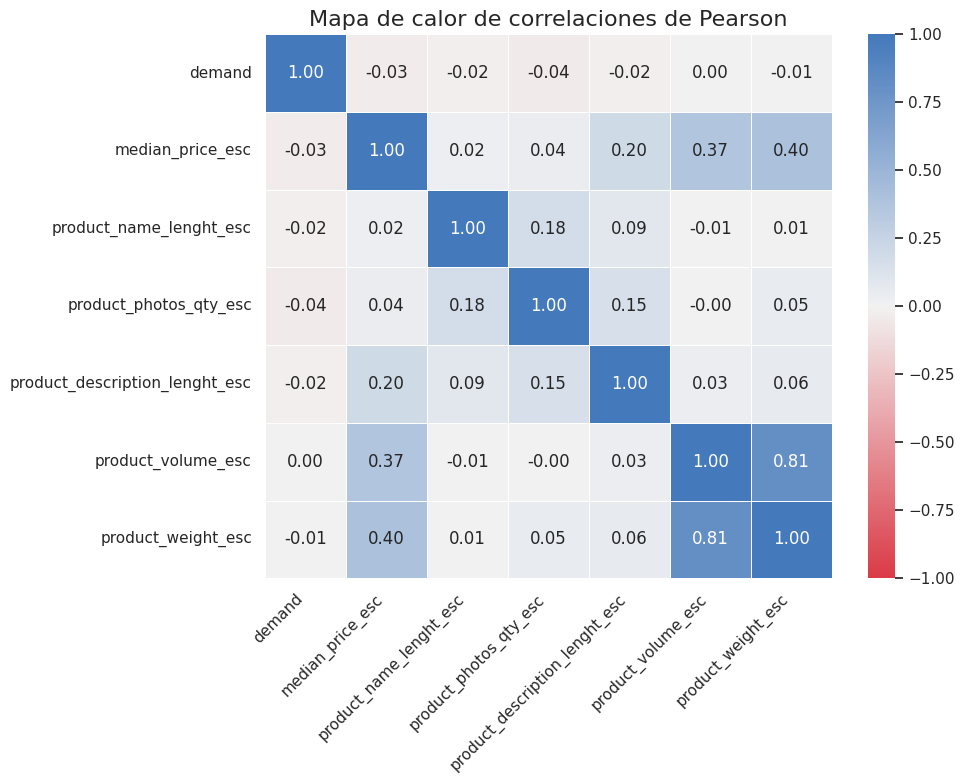

In [ ]:
# Seleccionar variables cuantitativas
corr_cols = ['demand'] + ['median_price_esc'] + scaled_cols

# Calcular la matriz de correlación de Pearson
correlation_matrix = df_corr_analysis[corr_cols].corr(method='pearson')

# Realizar el gráfico
plt.figure(figsize=(10, 8))

colors = ["red", "white", "blue"]
cmap_custom = sns.diverging_palette(10, 250, as_cmap=True)

sns.heatmap(correlation_matrix, annot=True, cmap=cmap_custom, fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones de Pearson', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **4.2.2. Serie semanal**

In [ ]:
# Obtener todas las combinaciones de producto-semana
grid_index_weekly = pd.MultiIndex.from_product([productos_validos_2, weekly_df_cal], names=['product_id', 'ds'])
weekly_df = pd.DataFrame(index=grid_index_weekly).reset_index()
weekly_df['ds'] = pd.to_datetime(weekly_df['ds'])

In [ ]:
# Crear dataframe auxiliar con la demanda de cada producto por semana
weekly_df_orders = df_filtrado_final.groupby(['product_id', 'week_of_year_name']).size().reset_index(name='demand')

In [ ]:
# Cruzar las tablas anteriores
weekly_df2 = weekly_df.merge(weekly_df_orders[['product_id', 'week_of_year_name', 'demand']],
                      left_on=['product_id', 'ds'],
                      right_on=['product_id', 'week_of_year_name'],
                      how='left')

# Eliminar columnas innecesarias
weekly_df2 = weekly_df2.drop(columns=['week_of_year_name'])

# Imputar 0 a los valores nulos de la demanda (semanas sin ventas)
weekly_df2['demand'] = weekly_df2['demand'].fillna(0).astype(int)

# Imprimir tabla
display(weekly_df2)

,product_id,ds,demand
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0
1,ac6c3623068f30de03045865e4e10089,2017-01-16,0
2,ac6c3623068f30de03045865e4e10089,2017-01-23,0
3,ac6c3623068f30de03045865e4e10089,2017-01-30,1
4,ac6c3623068f30de03045865e4e10089,2017-02-06,0
...,...,...,...
99871,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-16,0
99872,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-23,0
99873,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-30,0
99874,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-06,0


In [ ]:
# Calcular intermitencia del dataset (semanas con demanda nula)
freq_abs_cero = weekly_df2[weekly_df2['demand'] == 0].shape[0]
total_filas = weekly_df2.shape[0]
freq_rel_cero = (freq_abs_cero / total_filas) * 100

print(f"Frecuencia absoluta del valor 0 en 'demand': {freq_abs_cero}")
print(f"Frecuencia relativa del valor 0 en 'demand': {freq_rel_cero:.2f}%")

Frecuencia absoluta del valor 0 en 'demand': 81058
Frecuencia relativa del valor 0 en 'demand': 81.16%


In [ ]:
# Crear tabla de calendario a nivel semanal
cal_df_weekly = cal_df.groupby(['week_of_year_name','sin_woy','cos_woy']).agg(
    is_month_start_week=('is_month_start', 'sum'),
    is_month_end_week=('is_month_end', 'sum'),
    national_holidays_count=('is_national_holiday', 'sum'),
    is_black_friday_week=('is_black_friday', 'sum')
).reset_index()

# Filtrar por fechas de inicio y fin
cal_df_weekly = cal_df_weekly[(cal_df_weekly['week_of_year_name'] >= start_date) & (cal_df_weekly['week_of_year_name'] <= end_date)]

# Imprimir tabla
display(cal_df_weekly)

,week_of_year_name,sin_woy,cos_woy,is_month_start_week,is_month_end_week,national_holidays_count,is_black_friday_week
54,2017-01-09,0.238517,0.971138,0,0,0,0
55,2017-01-16,0.353452,0.935453,0,0,0,0
56,2017-01-23,0.463267,0.886219,0,0,0,0
57,2017-01-30,0.566372,0.824150,1,1,0,0
58,2017-02-06,0.661275,0.750144,0,0,0,0
...,...,...,...,...,...,...,...
133,2018-07-16,-0.343434,-0.939177,0,0,0,0
134,2018-07-23,-0.453769,-0.891119,0,0,0,0
135,2018-07-30,-0.557532,-0.830155,1,1,0,0
136,2018-08-06,-0.653220,-0.757168,0,0,0,0


In [ ]:
# Realizar el left join con tabla Order_Items para traer las variables deseadas
weekly_df3 = weekly_df2.merge(order_items_stats,
                            left_on='product_id',
                            right_on='product_id',
                            how='left')

# Quedarse sólo con las columnas necesarias
weekly_df3 = weekly_df3[['product_id','ds','demand_x','q2_price_esc']]
weekly_df3 = weekly_df3.rename(columns={'demand_x': 'demand',
                                      'q2_price_esc': 'median_price_esc'})

In [ ]:
# Realizar el left join con tabla Products para traer las variables deseadas
weekly_df3 = weekly_df3.merge(products_df_filtrado,
                            left_on='product_id',
                            right_on='product_id',
                            how='left')

# Quedarse sólo con las columnas necesarias
weekly_df3 = weekly_df3[['product_id','ds','demand','product_category_name','product_name_lenght_esc','product_description_lenght_esc','product_photos_qty_esc','product_volume_esc','product_weight_esc','median_price_esc']]

In [ ]:
# Realizar el left join con tabla Calendario para traer las variables deseadas
weekly_df3 = weekly_df3.merge(cal_df_weekly,
                            left_on='ds',
                            right_on='week_of_year_name',
                            how='left')

# Quedarse sólo con las columnas necesarias
weekly_df3 = weekly_df3.drop(['week_of_year_name'], axis=1)

# Renombrar columnas de forma adecuada para modelos de Nixtla
weekly_df3 = weekly_df3.rename(columns={'product_id': 'unique_id', 'demand': 'y'})

# Imprimir dataset
display(weekly_df3)

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,sin_woy,cos_woy,is_month_start_week,is_month_end_week,national_holidays_count,is_black_friday_week
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.238517,0.971138,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-16,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.353452,0.935453,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-23,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.463267,0.886219,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-30,1,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.566372,0.824150,1,1,0,0
4,ac6c3623068f30de03045865e4e10089,2017-02-06,0,garden_tools,0.90,-0.341732,0.0,2.746419,2.032258,1.546613,0.661275,0.750144,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99871,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-16,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.343434,-0.939177,0,0,0,0
99872,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-23,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.453769,-0.891119,0,0,0,0
99873,4cafc445fc7535c3b41b8978c0ce68dc,2018-07-30,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.557532,-0.830155,1,1,0,0
99874,4cafc445fc7535c3b41b8978c0ce68dc,2018-08-06,0,industry_commerce_and_business,0.44,0.760630,0.0,2.071612,3.193548,0.117871,-0.653220,-0.757168,0,0,0,0


##### **4.2.2.1. Gráfico de correlaciones a nivel semanal**

In [ ]:
# Obtener un dataframe auxiliar con la demanda a nivel de fecha
weekly_df_graph_2 = weekly_df_graph.merge(cal_df_weekly,
                                          left_on='week_of_year_name',
                                          right_on='week_of_year_name',
                                          how='left')

weekly_df_graph_2 = weekly_df_graph_2[(weekly_df_graph_2['week_of_year_name'] >= start_date) & (weekly_df_graph_2['week_of_year_name'] <= end_date)]

# Imprimir el dataframe
weekly_df_graph_2

,week_of_year_name,product_count,sin_woy,cos_woy,is_month_start_week,is_month_end_week,national_holidays_count,is_black_friday_week
14,2017-01-09,5,0.238517,0.971138,0.0,0.0,0.0,0.0
15,2017-01-16,22,0.353452,0.935453,0.0,0.0,0.0,0.0
16,2017-01-23,56,0.463267,0.886219,0.0,0.0,0.0,0.0
17,2017-01-30,82,0.566372,0.824150,1.0,1.0,0.0,0.0
18,2017-02-06,90,0.661275,0.750144,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
93,2018-07-16,582,-0.343434,-0.939177,0.0,0.0,0.0,0.0
94,2018-07-23,514,-0.453769,-0.891119,0.0,0.0,0.0,0.0
95,2018-07-30,683,-0.557532,-0.830155,1.0,1.0,0.0,0.0
96,2018-08-06,629,-0.653220,-0.757168,0.0,0.0,0.0,0.0


Las medidas de asociación correctas entre pares de variables continua-binaria (biserial puntual) y binaria-binaria (coeficiente phi) son matemáticamente equivalentes a la correlación de Pearson en estos casos.

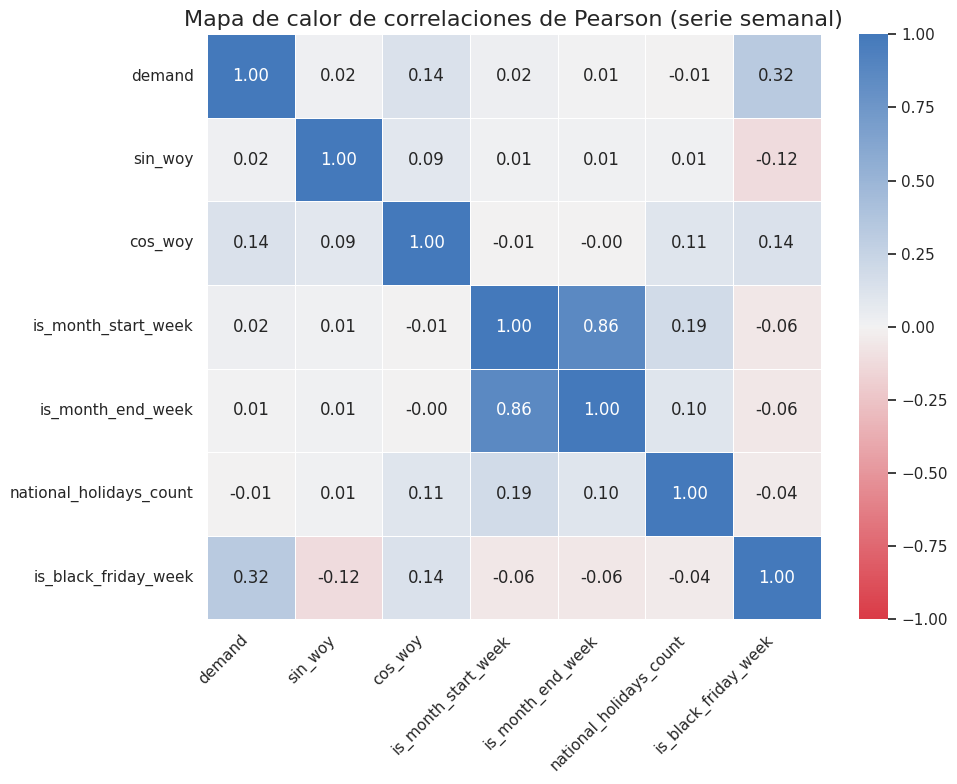

In [ ]:
# Renombrar la columna de demanda para el gráfico
weekly_df_graph_2 = weekly_df_graph_2.rename(columns={'product_count': 'demand'})

# Calcular la matriz de correlación de Pearson
numerical_cols = weekly_df_graph_2.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = weekly_df_graph_2[numerical_cols].corr(method='pearson')

# Realizar el gráfico
plt.figure(figsize=(10, 8))

colors = ["red", "white", "blue"]
cmap_custom = sns.diverging_palette(10, 250, as_cmap=True)

sns.heatmap(correlation_matrix, annot=True, cmap=cmap_custom, fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones de Pearson (serie semanal)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### **4.2.2.2. Gráfico de correlaciones a nivel producto**

In [ ]:
# Obtener un dataframe auxiliar con la demanda a nivel de producto
product_demand_agg = weekly_df2.groupby('product_id')['demand'].sum().reset_index()

# Agregar el resto de columnas de producto
df_corr_analysis = products_df_filtrado.merge(product_demand_agg, on='product_id', how='left')
df_corr_analysis = df_corr_analysis.merge(order_items_stats[['product_id','q2_price_esc']], on='product_id', how='left')
df_corr_analysis = df_corr_analysis.rename(columns={'q2_price_esc': 'median_price_esc'})

# Imputar la demanda nula con 0
df_corr_analysis['demand'] = df_corr_analysis['demand'].fillna(0).astype(int)

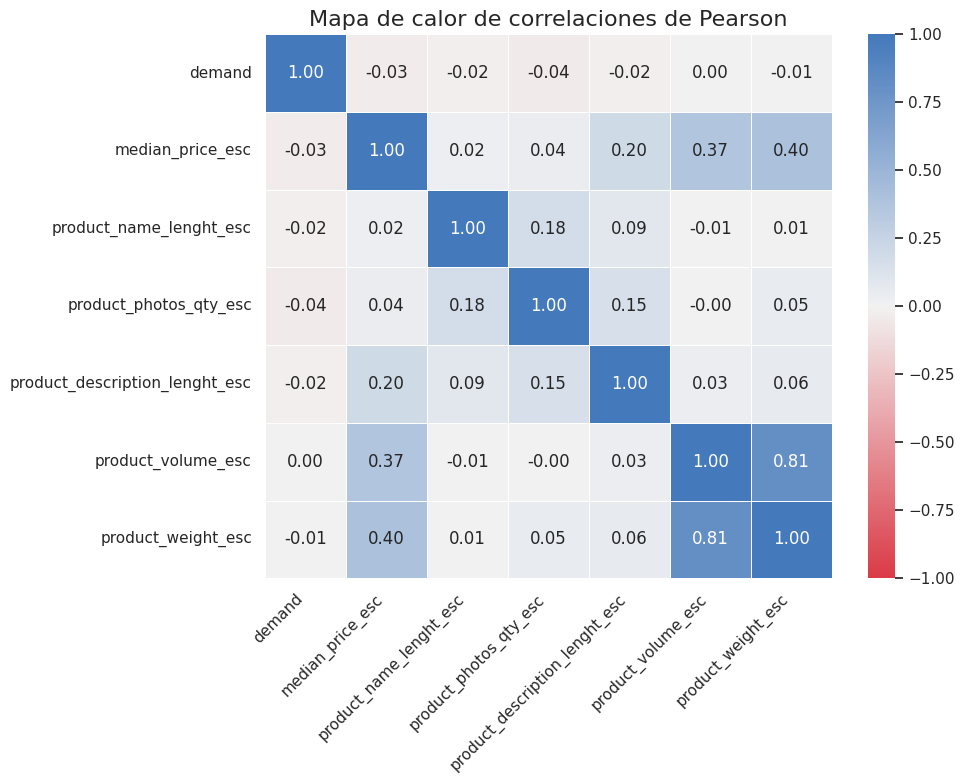

In [ ]:
# Seleccionar variables cuantitativas
corr_cols = ['demand'] + ['median_price_esc'] + scaled_cols

# Calcular la matriz de correlación de Pearson
correlation_matrix = df_corr_analysis[corr_cols].corr(method='pearson')

# Realizar el gráfico
plt.figure(figsize=(10, 8))

colors = ["red", "white", "blue"]
cmap_custom = sns.diverging_palette(10, 250, as_cmap=True)

sns.heatmap(correlation_matrix, annot=True, cmap=cmap_custom, fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Mapa de calor de correlaciones de Pearson', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## **5. EDA - Parte 2**

### **5.1. Muestra de productos**

#### **5.1.1 Serie diaria**

In [ ]:
# Obtener tabla auxiliar con la intermitencia de cada producto
product_info_daily = daily_df3.groupby('unique_id').agg(
    demand_zero_count=('y', lambda x: (x == 0).sum())
).reset_index()

product_info_daily['demand_zero_percentage'] = (product_info_daily['demand_zero_count'] / (end_date_dt - start_date_dt).days) * 100

# Ordenar la tabla por 'demand_zero_count' de forma descendente
product_info_daily = product_info_daily.sort_values(by='demand_zero_count', ascending=False)

# Añadir la columna de demanda por producto
aux = df_filtrado_final.groupby('product_id').size().reset_index(name='y')
aux = aux.sort_values(by='y', ascending=False).reset_index(drop=True)
aux['rank'] = aux.index + 1
product_info_daily = product_info_daily.merge(aux,
                                              left_on='unique_id',
                                              right_on='product_id',
                                              how='left')

# Imprimir tabla
display(product_info_daily)

,unique_id,demand_zero_count,demand_zero_percentage,product_id,y,rank
0,952e73f7e8bee61569a32b35c19bc981,580,98.807496,952e73f7e8bee61569a32b35c19bc981,8,1189
1,157ee978f4fcdf8984b0bb33a6687fde,580,98.807496,157ee978f4fcdf8984b0bb33a6687fde,10,1151
2,5f0bdec2fb222061ed8fe52586a5957d,579,98.637138,5f0bdec2fb222061ed8fe52586a5957d,9,1188
3,783caabd539c4079ec08423e30719fba,579,98.637138,783caabd539c4079ec08423e30719fba,11,1109
4,9c7bdf67b06b419aefb93cfdfc96c55d,579,98.637138,9c7bdf67b06b419aefb93cfdfc96c55d,10,1163
...,...,...,...,...,...,...
1184,389d119b48cf3043d311335e499d9c6b,399,67.972743,389d119b48cf3043d311335e499d9c6b,390,4
1185,154e7e31ebfa092203795c972e5804a6,399,67.972743,154e7e31ebfa092203795c972e5804a6,274,9
1186,d1c427060a0f73f6b889a5c7c61f2ac4,394,67.120954,d1c427060a0f73f6b889a5c7c61f2ac4,330,7
1187,422879e10f46682990de24d770e7f83d,392,66.780239,422879e10f46682990de24d770e7f83d,484,2


In [ ]:
# Seleccionar una muestra de productos marginales
muestra_productos_low_diaria = product_info_daily['unique_id'][0:9].tolist()

# Seleccionar una muestra de productos estrella
muestra_productos_top_diaria = product_info_daily['unique_id'][-9:].tolist()

In [ ]:
# Obtener estadísticos
product_info_daily.describe()

,demand_zero_count,demand_zero_percentage,y,rank
count,1189.000000,1189.000000,1189.000000,1189.000000
mean,563.698907,96.030478,31.736754,595.000000
std,23.897723,4.071162,43.557410,343.379042
min,325.000000,55.366269,8.000000,1.000000
25%,562.000000,95.741056,13.000000,298.000000
50%,572.000000,97.444634,19.000000,595.000000
75%,576.000000,98.126065,32.000000,892.000000
max,580.000000,98.807496,520.000000,1189.000000


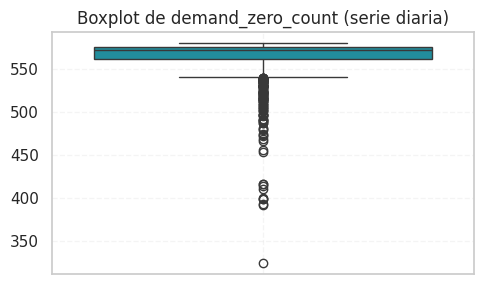

In [ ]:
# Realizar gráfico
plt.figure(figsize=(5, 3))
sns.boxplot(y=product_info_daily['demand_zero_count'], color='#0E9EB1')
plt.title('Boxplot de demand_zero_count (serie diaria)')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# Calcular la mediana de los campos
product_info_daily_median = product_info_daily[product_info_daily['demand_zero_count'] == product_info_daily['demand_zero_count'].median()]
display(product_info_daily_median.head())

,unique_id,demand_zero_count,demand_zero_percentage,product_id,y,rank
545,5ccdfc35d9cff8db4fa46b83d5712899,572,97.444634,5ccdfc35d9cff8db4fa46b83d5712899,19,576
546,7f457254a89d62960399e075711b3deb,572,97.444634,7f457254a89d62960399e075711b3deb,17,657
547,a334304f952399f2161225628a9d2891,572,97.444634,a334304f952399f2161225628a9d2891,20,549
548,247fa5b4e2f524a22b21ef256ffc23e4,572,97.444634,247fa5b4e2f524a22b21ef256ffc23e4,19,573
549,b4b817e5f2c4efc8253b4b679c653847,572,97.444634,b4b817e5f2c4efc8253b4b679c653847,18,617


In [ ]:
# Seleccionar una muestra de productos representativos
muestra_productos_median_diaria = product_info_daily_median['unique_id'].tolist()

# Juntar todas las muestras de productos de la serie diaria
muestra_productos_diaria = muestra_productos_low_diaria + muestra_productos_median_diaria + muestra_productos_top_diaria

#### **5.1.2. Serie semanal**

In [ ]:
# Obtener tabla auxiliar con la intermitencia de cada producto
product_info_weekly = weekly_df3.groupby('unique_id').agg(
    demand_zero_count=('y', lambda x: (x == 0).sum())
).reset_index()

product_info_weekly['demand_zero_percentage'] = (product_info_weekly['demand_zero_count'] / int(np.floor((end_date_dt - start_date_dt).days / 7))) * 100

# Ordenar la tabla por 'demand_zero_count' de forma descendente
product_info_weekly = product_info_weekly.sort_values(by='demand_zero_count', ascending=False)

# Añadir la columna de demanda por producto
product_info_weekly = product_info_weekly.merge(aux,
                                              left_on='unique_id',
                                              right_on='product_id',
                                              how='left')

# Imprimir tabla
display(product_info_weekly)

,unique_id,demand_zero_count,demand_zero_percentage,product_id,y,rank
0,157ee978f4fcdf8984b0bb33a6687fde,78,93.975904,157ee978f4fcdf8984b0bb33a6687fde,10,1151
1,e9b3cf27d68caa64832c4a7c460abcb9,78,93.975904,e9b3cf27d68caa64832c4a7c460abcb9,10,1171
2,b75a056d7d03227c3a3b60e9ccf518c9,77,92.771084,b75a056d7d03227c3a3b60e9ccf518c9,11,1087
3,2fea0f2cec6b6324a277d4a61c2ed2c6,77,92.771084,2fea0f2cec6b6324a277d4a61c2ed2c6,57,125
4,7935ddc510afb7d08989660b382b7f26,77,92.771084,7935ddc510afb7d08989660b382b7f26,16,737
...,...,...,...,...,...,...
1184,154e7e31ebfa092203795c972e5804a6,18,21.686747,154e7e31ebfa092203795c972e5804a6,274,9
1185,2b4609f8948be18874494203496bc318,17,20.481928,2b4609f8948be18874494203496bc318,251,11
1186,d1c427060a0f73f6b889a5c7c61f2ac4,16,19.277108,d1c427060a0f73f6b889a5c7c61f2ac4,330,7
1187,7c1bd920dbdf22470b68bde975dd3ccf,10,12.048193,7c1bd920dbdf22470b68bde975dd3ccf,219,13


In [ ]:
# Seleccionar una muestra de productos marginales
muestra_productos_low_semanal = product_info_weekly['unique_id'][0:9].tolist()

# Seleccionar una muestra de productos estrella
muestra_productos_top_semanal = product_info_weekly['unique_id'][-9:].tolist()

In [ ]:
# Obtener estadísticos
product_info_weekly.describe()

,demand_zero_count,demand_zero_percentage,y,rank
count,1189.000000,1189.000000,1189.000000,1189.000000
mean,68.173255,82.136452,31.736754,595.000000
std,9.120329,10.988348,43.557410,343.379042
min,10.000000,12.048193,8.000000,1.000000
25%,66.000000,79.518072,13.000000,298.000000
50%,71.000000,85.542169,19.000000,595.000000
75%,74.000000,89.156627,32.000000,892.000000
max,78.000000,93.975904,520.000000,1189.000000


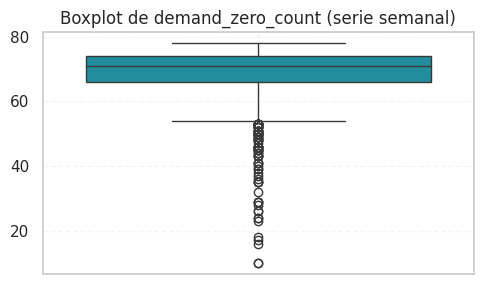

In [ ]:
# Realizar gráfico
plt.figure(figsize=(5, 3))
sns.boxplot(y=product_info_weekly['demand_zero_count'], color='#0E9EB1')
plt.title('Boxplot de demand_zero_count (serie semanal)')
plt.ylabel('')
plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# Calcular la mediana de los campos
product_info_weekly_median = product_info_weekly[product_info_weekly['demand_zero_count'] == product_info_weekly['demand_zero_count'].median()]
display(product_info_weekly_median)

,unique_id,demand_zero_count,demand_zero_percentage,product_id,y,rank
569,ffc9caf33e2d1e9f44e3e06da19085f7,71,85.542169,ffc9caf33e2d1e9f44e3e06da19085f7,27,370
570,ff29d8cb1cd0cd5ea37b80dac9939e1c,71,85.542169,ff29d8cb1cd0cd5ea37b80dac9939e1c,23,433
571,c1617123e66d2491ca93ceadfd36203e,71,85.542169,c1617123e66d2491ca93ceadfd36203e,20,544
572,bfc0d01be79d9038c7720f983bf954e0,71,85.542169,bfc0d01be79d9038c7720f983bf954e0,15,773
573,1e618d311a1b7f88a9d96ec50aa85582,71,85.542169,1e618d311a1b7f88a9d96ec50aa85582,21,496
...,...,...,...,...,...,...
644,0bdd9a52d192d64770e33ae559512478,71,85.542169,0bdd9a52d192d64770e33ae559512478,15,766
645,4293865e4ead3d446609086b4cfedb4f,71,85.542169,4293865e4ead3d446609086b4cfedb4f,14,878
646,42eb5329dd0ee3d76d135ce04c84451b,71,85.542169,42eb5329dd0ee3d76d135ce04c84451b,13,916
647,c9dbe2eec19a8093cb5ac57486531c18,71,85.542169,c9dbe2eec19a8093cb5ac57486531c18,17,655


In [ ]:
# Seleccionar una muestra de productos representativos
muestra_productos_median_semanal = product_info_weekly_median['unique_id'].tolist()

# Juntar todas las muestras de productos de la serie semanal
muestra_productos_semanal = muestra_productos_low_semanal + muestra_productos_median_semanal + muestra_productos_top_semanal

### **5.2. Gráfico de líneas de muestra de productos**

Se selecciona como muestra de productos marginales, representativos y estrella los coincidentes a nivel diario y semanal en estas categorías

In [ ]:
# Seleccionar los productos marginales coincidentes a nivel diario y semanal
muestra_productos_low_comun = list(set(muestra_productos_low_diaria) & set(muestra_productos_low_semanal))
print("Productos comunes de baja demanda (diaria y semanal):")
print(muestra_productos_low_comun)

# Seleccionar los productos representativos coincidentes a nivel diario y semanal
muestra_productos_median_comun = list(set(muestra_productos_median_diaria) & set(muestra_productos_median_semanal))
print("\nProductos comunes de baja demanda (diaria y semanal):")
print(muestra_productos_median_comun)

# Seleccionar los productos estrella coincidentes a nivel diario y semanal
muestra_productos_top_comun = list(set(muestra_productos_top_diaria) & set(muestra_productos_top_semanal))
print("\nProductos comunes de baja demanda (diaria y semanal):")
print(muestra_productos_top_comun)

Productos comunes de baja demanda (diaria y semanal):
['e9b3cf27d68caa64832c4a7c460abcb9', '783caabd539c4079ec08423e30719fba', '952e73f7e8bee61569a32b35c19bc981', '157ee978f4fcdf8984b0bb33a6687fde', '9c7bdf67b06b419aefb93cfdfc96c55d']

Productos comunes de baja demanda (diaria y semanal):
['de480e3ae31eea2d2d97d694c43172fc', '64315bd8c0c47303179dd2e25b579d00', 'e3425df9bd51be69917273c9dd92ed5e', '5ccdfc35d9cff8db4fa46b83d5712899', 'c8abdbe349a97073e7aebc795be55bd8', 'c9dbe2eec19a8093cb5ac57486531c18', '5115d8cd6438c0c4d8abdf38d5d41ebd', '803f77475e1b51b47f1bfec4f2ec353f']

Productos comunes de baja demanda (diaria y semanal):
['154e7e31ebfa092203795c972e5804a6', '99a4788cb24856965c36a24e339b6058', '389d119b48cf3043d311335e499d9c6b', '7c1bd920dbdf22470b68bde975dd3ccf', 'd1c427060a0f73f6b889a5c7c61f2ac4', '2b4609f8948be18874494203496bc318']


In [ ]:
# Selección final de un producto marginal de entre los coincidentes
muestra_productos_low = ['157ee978f4fcdf8984b0bb33a6687fde']
print('Producto marginal seleccionado: ', muestra_productos_low)

# Selección final de un producto representativo de entre los coincidentes
muestra_productos_median = ['64315bd8c0c47303179dd2e25b579d00']
print('Producto representativo seleccionado: ', muestra_productos_median)

# Selección final de un producto estrella de entre los coincidentes
muestra_productos_top = ['422879e10f46682990de24d770e7f83d']
print('Producto estrella seleccionado: ', muestra_productos_top)

# Juntar los productos seleccionados
muestra_productos = muestra_productos_low + muestra_productos_median + muestra_productos_top

Producto marginal seleccionado:  ['157ee978f4fcdf8984b0bb33a6687fde']
Producto representativo seleccionado:  ['64315bd8c0c47303179dd2e25b579d00']
Producto estrella seleccionado:  ['422879e10f46682990de24d770e7f83d']


#### **5.2.1. Serie diaria**

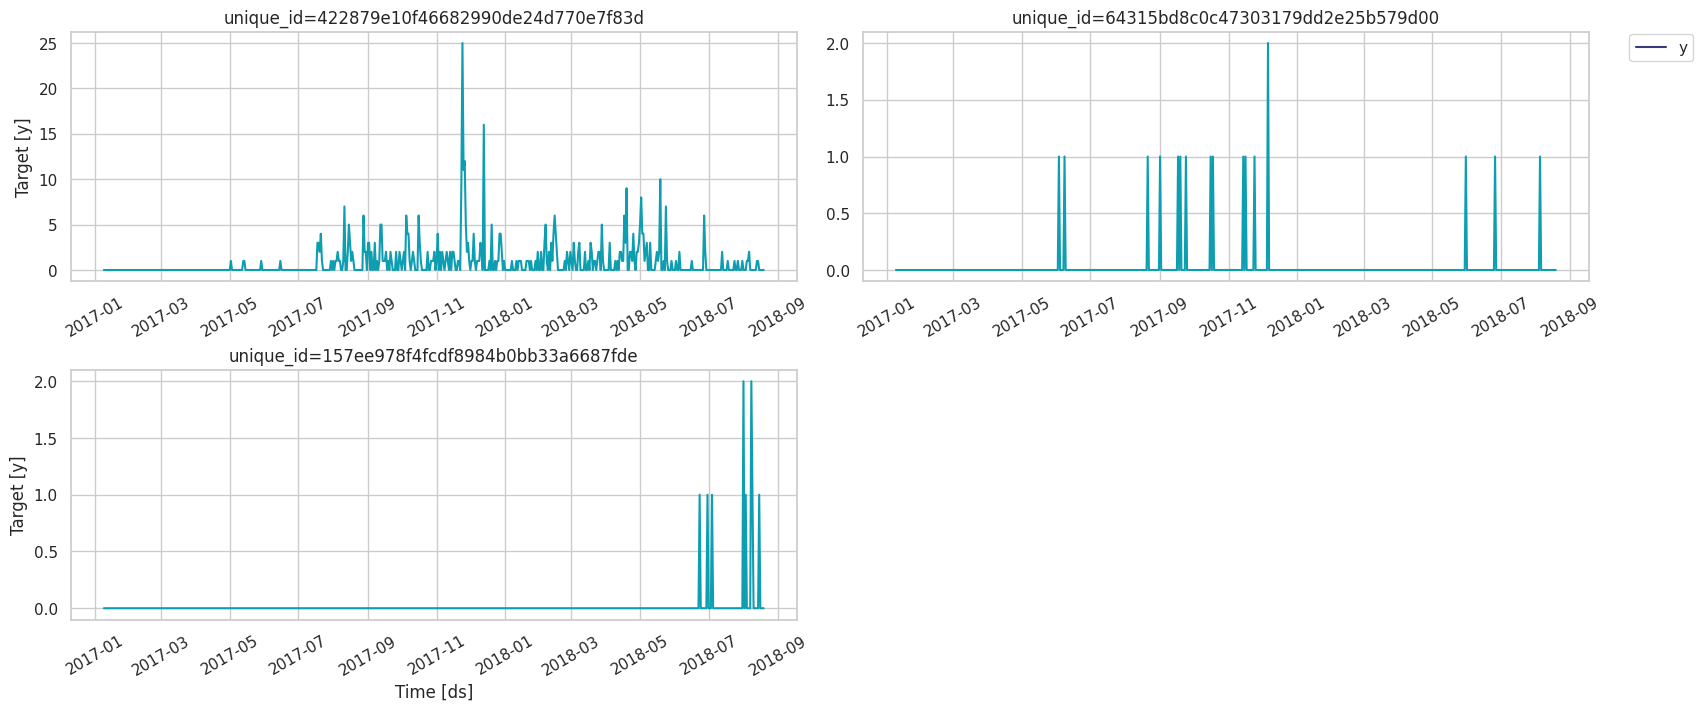

In [ ]:
# Filtrar dataframe por productos seleccionados
daily_df_muestra = daily_df3[daily_df3['unique_id'].isin(muestra_productos)][['unique_id','ds','y']]

# Realizar los gráficos
fig = StatsForecast.plot(
    daily_df_muestra,
    engine='matplotlib',
    plot_random=False,
)

for ax in fig.get_axes():
    for line in ax.get_lines():
        line.set_color('#0E9EB1')

fig

In [ ]:
# Descargar dataframe
daily_df_muestra.to_csv(os.path.join(ruta_output, 'daily_df_muestra.csv'), index=False, sep=';', decimal=',')

#### **5.2.2. Serie semanal**

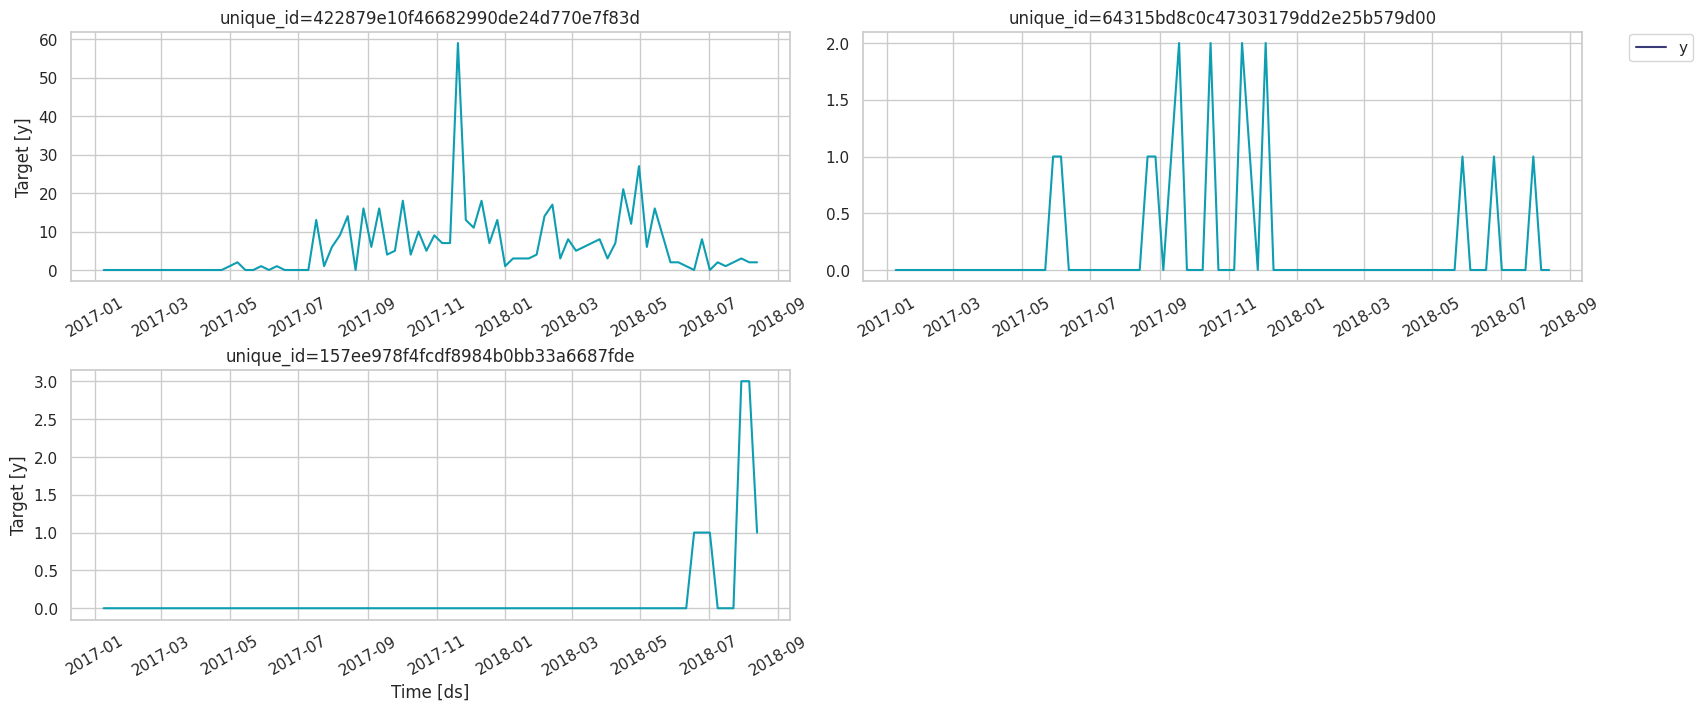

In [ ]:
# Filtrar dataframe por productos seleccionados
weekly_df_muestra = weekly_df3[weekly_df3['unique_id'].isin(muestra_productos)][['unique_id','ds','y']]

# Realizar los gráficos
fig = StatsForecast.plot(
    weekly_df_muestra,
    engine='matplotlib',
    plot_random=False,
)

for ax in fig.get_axes():
    for line in ax.get_lines():
        line.set_color('#0E9EB1')

fig

In [ ]:
# Descargar dataframe
weekly_df_muestra.to_csv(os.path.join(ruta_output, 'weekly_df_muestra.csv'), index=False, sep=';', decimal=',')

## **6. Modelado**

### **6.1. Serie diaria**

In [ ]:
# Ajustar tipo de las variables categóricas
for col in ['product_category_name','day_of_week_name']:
    daily_df3[col] = daily_df3[col].astype('category')

In [ ]:
# Seleccionar variables de entrada específicas para cada modelo
daily_df_lgbm = daily_df3.drop(['sin_dow','cos_dow'], axis=1)
daily_df_nhits = daily_df3.drop('day_of_week_name', axis=1)
daily_df_tft = daily_df3.drop('day_of_week_name', axis=1)

In [ ]:
# Descargar dataframes
# daily_df_lgbm.to_csv(os.path.join(ruta_output, 'daily_df_lgbm.csv'), index=False, sep=';', decimal=',')
# daily_df_nhits.to_csv(os.path.join(ruta_output, 'daily_df_nhits.csv'), index=False, sep=';', decimal=',')
daily_df_tft.to_csv(os.path.join(ruta_output, 'daily_df_tft.csv'), index=False, sep=';', decimal=',')

#### **6.1.1. LightGBM**

In [ ]:
# Imprimir algunas filas
display(daily_df_lgbm.head())

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,day_of_week_name,cos_doy,sin_doy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,Monday,0.988039,0.154204,0,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-10,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,Tuesday,0.985240,0.171177,0,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-11,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,Wednesday,0.982150,0.188099,0,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-12,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,Thursday,0.978769,0.204966,0,0,0,0,0
4,ac6c3623068f30de03045865e4e10089,2017-01-13,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,Friday,0.975099,0.221772,0,0,0,0,0


In [ ]:
# Definir variables estáticas
exog_estaticas_lgbm = ['product_category_name', 'product_name_lenght_esc', 'product_description_lenght_esc', 'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc', 'median_price_esc']

# Definir variables dinámicas
exog_dinamicas_lgbm= ['day_of_week_name', 'cos_doy', 'sin_doy', 'is_weekend', 'is_month_start', 'is_month_end', 'is_national_holiday', 'is_black_friday']

##### **6.1.1.1. Optimización de hiperparámetros**

In [ ]:
# Función para el cálculo del WAPE para la optimización
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

# Configurar el motor de búsqueda de la optimización
semilla_optuna = TPESampler(seed=16)

# Configurar el espacio de búsqueda de los hiperparámetros
def objective(trial):
    lgbm_config = {
        'objective': 'poisson',
        'random_state': 88,
        'verbose': -1,
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.05, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 5, 15)
    }

    # Instanciar el modelo
    modelo_lgbm = lgb.LGBMRegressor(**lgbm_config)

    # Crear el pipeline predictivo
    fcst_lgbm = MLForecast(
        models={'AutoLGBM': modelo_lgbm},
        freq='D',
        lags=[1, 2, 3, 7, 14, 21, 28],
        lag_transforms={
            7: [RollingMean(window_size=7), RollingMean(window_size=28)]
        }
    )

    # Ejecutar la validación cruzada
    cv_lgbm_inner = fcst_lgbm.cross_validation(
        df=daily_df_lgbm,
        h=14,
        n_windows=2,
        step_size=14,
        static_features=exog_estaticas_lgbm,
        id_col='unique_id',
        time_col='ds',
        target_col='y'
    )

    # Cálculo del WAPE a optimizar
    y_real = cv_lgbm_inner['y'].values
    y_pred = cv_lgbm_inner['AutoLGBM'].values

    if np.sum(y_real) == 0:
        return np.inf

    return wape(y_real, y_pred)

# Ejecutar la optimización
study_lgbm = optuna.create_study(direction='minimize', sampler=semilla_optuna)
study_lgbm.optimize(objective, n_trials=30)

# Mostrar los hiperparámetros óptimos
mejores_hiperparametros_lgbm = study_lgbm.best_params

print("\n--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO LIGHTGBM ---")
print(f"Mejor WAPE de validación en Optuna: {study_lgbm.best_value:.4f} ({study_lgbm.best_value:.2%})")
for parametro, valor in mejores_hiperparametros_lgbm.items():
    print(f"{parametro}: {valor}")

[I 2026-09-16 14:18:11,618] A new study created in memory with name: no-name-c61a4342-7da7-4fd1-aed6-6d96ad375b9b
[I 2026-09-16 14:18:20,385] Trial 0 finished with value: 2.30449841349926 and parameters: {'learning_rate': 0.0023953271977722366, 'n_estimators': 309, 'num_leaves': 64, 'max_depth': 5}. Best is trial 0 with value: 2.30449841349926.
[I 2026-09-16 14:18:26,941] Trial 1 finished with value: 2.328989723925561 and parameters: {'learning_rate': 0.004100789444448252, 'n_estimators': 189, 'num_leaves': 75, 'max_depth': 6}. Best is trial 0 with value: 2.30449841349926.
[I 2026-09-16 14:18:38,234] Trial 2 finished with value: 2.245301553803729 and parameters: {'learning_rate': 0.001316678788682426, 'n_estimators': 477, 'num_leaves': 65, 'max_depth': 5}. Best is trial 2 with value: 2.245301553803729.
[I 2026-09-16 14:18:44,047] Trial 3 finished with value: 3.0022251483453726 and parameters: {'learning_rate': 0.016894469235160477, 'n_estimators': 163, 'num_leaves': 40, 'max_depth': 8}


--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO LIGHTGBM ---
Mejor WAPE de validación en Optuna: 1.8051 (180.51%)
learning_rate: 0.0013169957355328183
n_estimators: 111
num_leaves: 24
max_depth: 7


##### **6.1.1.2. Ajuste del modelo definitivo**

In [ ]:
# Seleccionar los mejores hiperparámetros
mejores_params_lgbm = study_lgbm.best_params
mejores_params_lgbm['objective'] = 'poisson'
mejores_params_lgbm['random_state'] = 88
mejores_params_lgbm['verbose'] = -1

# Instanciar el modelo definitivo con los hiperparámetros óptimos
modelo_final_lgbm = lgb.LGBMRegressor(**mejores_params_lgbm)

# Crear el pipeline predictivo definitivo
fcst_final_lgbm = MLForecast(
    models={'LGBM_Final': modelo_final_lgbm}, # Nombre limpio para la columna predictiva
    freq='D',
    lags=[1, 2, 3, 7, 14, 21, 28],
    lag_transforms={
        7: [RollingMean(window_size=7), RollingMean(window_size=28)]
    }
)

# Ejecutar la validación cruzada definitiva
cv_lgbm = fcst_final_lgbm.cross_validation(
    df=daily_df_lgbm,
    h=14,
    n_windows=2,
    step_size=14,
    static_features=exog_estaticas_lgbm,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

In [ ]:
# Seleccionar sólo las columnas necesarias
columnas_guardar_lgbm = ['unique_id', 'ds', 'y', 'LGBM_Final']
predicciones_test_lgbm = cv_lgbm[columnas_guardar_lgbm].copy()

# Asegurar límite cero (evitar predicciones negativas por seguridad)
predicciones_test_lgbm['LGBM_Final'] = predicciones_test_lgbm['LGBM_Final'].clip(lower=0)

# Imprimir algunas filas
display(predicciones_test_lgbm.head())

# Descargar el dataframe
# predicciones_test_lgbm.to_csv(os.path.join(ruta_output, 'predicciones_test_lgbm.csv'), index=False, sep=';', decimal=',')

,unique_id,ds,y,LGBM_Final
0,005030ef108f58b46b78116f754d8d38,2018-07-23,0,0.053298
1,005030ef108f58b46b78116f754d8d38,2018-07-24,0,0.060674
2,005030ef108f58b46b78116f754d8d38,2018-07-25,0,0.060674
3,005030ef108f58b46b78116f754d8d38,2018-07-26,0,0.060674
4,005030ef108f58b46b78116f754d8d38,2018-07-27,0,0.060674


#### **6.1.2. N-HiTS**

In [ ]:
# Imprimir algunas filas
display(daily_df_nhits.head())

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,cos_dow,sin_dow,cos_doy,sin_doy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,1.000000,0.000000,0.988039,0.154204,0,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-10,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.623490,0.781831,0.985240,0.171177,0,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-11,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,-0.222521,0.974928,0.982150,0.188099,0,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-12,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,-0.900969,0.433884,0.978769,0.204966,0,0,0,0,0
4,ac6c3623068f30de03045865e4e10089,2017-01-13,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,-0.900969,-0.433884,0.975099,0.221772,0,0,0,0,0


In [ ]:
# Crear el dataframe estático (una sola fila por producto)
exog_estaticas_nhits = ['product_category_name', 'product_name_lenght_esc', 'product_description_lenght_esc', 'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc', 'median_price_esc']
static_df = daily_df_nhits[['unique_id'] + exog_estaticas_nhits].drop_duplicates().reset_index(drop=True)

# Dejar sólo las variables dinámicas en el dataframe histórico
exog_dinamicas_nhits = ['is_weekend', 'is_month_start', 'is_month_end', 'sin_dow', 'cos_dow', 'sin_doy', 'cos_doy', 'is_national_holiday', 'is_black_friday']
df_dinamico = daily_df_nhits[['unique_id', 'ds', 'y'] + exog_dinamicas_nhits]

##### **6.1.2.1. Optimización de hiperparámetros**

In [ ]:
# Configurar el espacio de búsqueda de los hiperparámetros
nhits_config = {
    "learning_rate": tune.loguniform(1e-4, 1e-2),
    "input_size": tune.choice([14, 28, 56]),
    "max_steps": tune.choice([500, 1000]),
    "n_blocks": tune.choice([[1, 1, 1], [2, 2, 2]]),
    "random_seed": 91,
    "stat_exog_list": exog_estaticas_nhits,
    "futr_exog_list": exog_dinamicas_nhits,
    "start_padding_enabled": True
}

# Instanciar la configuración del modelo
modelo_nhits = AutoNHITS(
    h=14,
    loss=DistributionLoss(distribution='Poisson'),
    config=nhits_config,
    num_samples=10
)


##### **6.1.2.2. Ajuste de modelo definitivo**

In [ ]:
# Instanciar el modelo
nf = NeuralForecast(models=[modelo_nhits], freq='D')

# Ejecutar la validación cruzada
cv_nhits = nf.cross_validation(
    df=df_dinamico,
    static_df=static_df,
    n_windows=2,
    step_size=14
)

2026-09-16 14:21:46,850	INFO worker.py:2024 -- Started a local Ray instance.
2026-09-16 14:21:50,287	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.


+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-09-16_14-21-40   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-09-16_14-21-40
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-09-16_14-21-40_568139_3542/artifacts/2026-09-16_14-21-50/_train_tune_2026-09-16_14-21-40/driver_artifacts`


(_train_tune pid=6448) /usr/local/lib/python3.13/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=6448) Seed set to 91
(_train_tune pid=6448) GPU available: True (cuda), used: True
(_train_tune pid=6448) TPU available: False, using: 0 TPU cores
(_train_tune pid=6448) You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
(_train_tune pid=6448) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(_train_tune pid=6448) 
(_train_tune pid=6448)   | Name                | Type             | Params | Mode 
(_train_tune pid=6448) 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]


(_train_tune pid=6448) /usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Imprimir algunas predicciones
# display(cv_nhits.head())

# Mostrar los hiperparámetros y resultados óptimos
auto_nhits_entrenado = nf.models[0]
mejor_resultado_nhits = auto_nhits_entrenado.results.get_best_result()
mejores_hiperparametros_nhits = mejor_resultado_nhits.config

print("\n--- HIPERPARÁMETROS ÓPTIMOS DE N-HiTS ---")
for parametro, valor in mejores_hiperparametros_nhits.items():
    # Filtrar las listas de variables exógenas para limpiar la salida
    if parametro not in ['stat_exog_list', 'futr_exog_list']:
        print(f"{parametro}: {valor}")


--- HIPERPARÁMETROS ÓPTIMOS DE N-HiTS ---
learning_rate: 0.0008072271845269063
input_size: 56
max_steps: 500
n_blocks: [1, 1, 1]
random_seed: 91
start_padding_enabled: True
h: 14
loss: DistributionLoss()
valid_loss: DistributionLoss()


In [ ]:
# Seleccionar sólo las columnas necesarias
columnas_guardar = ['unique_id', 'ds', 'y', 'AutoNHITS-median']
predicciones_test_nhits = cv_nhits[columnas_guardar].copy()

# Renombrar las columnas
predicciones_test_nhits = predicciones_test_nhits.rename(columns={'AutoNHITS-median': 'NHITS_Final'})

# Imprimir algunas filas
display(predicciones_test_nhits.head())

# Descargar el dataframe
# predicciones_test_nhits.to_csv(os.path.join(ruta_output, 'predicciones_test_nhits.csv'), index=False, sep=';', decimal=',')

,unique_id,ds,y,NHITS_Final
0,005030ef108f58b46b78116f754d8d38,2018-07-23,0,0.0
1,005030ef108f58b46b78116f754d8d38,2018-07-24,0,0.0
2,005030ef108f58b46b78116f754d8d38,2018-07-25,0,0.0
3,005030ef108f58b46b78116f754d8d38,2018-07-26,0,0.0
4,005030ef108f58b46b78116f754d8d38,2018-07-27,0,0.0


#### **6.1.3. TFT**

In [ ]:
# Imprimir algunas filas
display(daily_df_tft.head())

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,cos_dow,sin_dow,cos_doy,sin_doy,is_weekend,is_month_start,is_month_end,is_national_holiday,is_black_friday
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,1.000000,0.000000,0.988039,0.154204,0,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-10,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.623490,0.781831,0.985240,0.171177,0,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-11,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,-0.222521,0.974928,0.982150,0.188099,0,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-12,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,-0.900969,0.433884,0.978769,0.204966,0,0,0,0,0
4,ac6c3623068f30de03045865e4e10089,2017-01-13,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,-0.900969,-0.433884,0.975099,0.221772,0,0,0,0,0


In [ ]:
# Crear el dataframe estático (una sola fila por producto)
exog_estaticas_tft = ['product_category_name', 'product_name_lenght_esc', 'product_description_lenght_esc', 'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc', 'median_price_esc']
static_df = daily_df_tft[['unique_id'] + exog_estaticas_tft].drop_duplicates().reset_index(drop=True)

# Dejar sólo las variables dinámicas en el dataframe histórico
exog_dinamicas_tft = ['is_weekend', 'is_month_start', 'is_month_end', 'sin_dow', 'cos_dow', 'sin_doy', 'cos_doy', 'is_national_holiday', 'is_black_friday']
df_dinamico = daily_df_tft[['unique_id', 'ds', 'y'] + exog_dinamicas_tft]

##### **6.1.3.1. Optimización de hiperparámetros**

In [ ]:
# Configurar el espacio de búsqueda de los hiperparámetros
tft_config = {
    "learning_rate": tune.loguniform(1e-4, 1e-2),
    "input_size": tune.choice([14, 28, 56]),
    "hidden_size": tune.choice([32, 64]),
    "max_steps": tune.choice([500, 1000]),
    "random_seed": 35,
    "stat_exog_list": exog_estaticas_tft,
    "futr_exog_list": exog_dinamicas_tft
}

# Instanciar la configuración del modelo
modelo_tft = AutoTFT(
    h=14,
    loss=DistributionLoss(distribution='Poisson'),
    config=tft_config,
    num_samples=10
)


##### **6.1.3.2. Ajuste de modelo definitivo**

In [ ]:
# Instanciar el modelo
nf_tft = NeuralForecast(models=[modelo_tft], freq='D')

# Ejecutar la validación cruzada
cv_tft = nf_tft.cross_validation(
    df=df_dinamico,
    static_df=static_df,
    n_windows=2,
    step_size=14
)

+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-09-16_14-26-54   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-09-16_14-26-54
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-09-16_14-21-40_568139_3542/artifacts/2026-09-16_14-26-54/_train_tune_2026-09-16_14-26-54/driver_artifacts`


(_train_tune pid=8381) /usr/local/lib/python3.13/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=8381) Seed set to 35
(_train_tune pid=8381) GPU available: True (cuda), used: True
(_train_tune pid=8381) TPU available: False, using: 0 TPU cores
(_train_tune pid=8381) You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
(_train_tune pid=8381) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(_train_tune pid=8381) 
(_train_tune pid=8381)    | Name                    | Type                     | Params | Mode 
(_train_tu

Epoch 2:  53%|█████▎    | 20/38 [00:02<00:02,  6.76it/s, v_num=0, train_loss_step=0.250, train_loss_epoch=0.324]
(_train_tune pid=8381) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/38 [00:00<?, ?it/s]
(_train_tune pid=8381) 
Validation DataLoader 0:  53%|█████▎    | 20/38 [00:00<00:00, 56.34it/s]
(_train_tune pid=8381) 
Epoch 5:   0%|          | 0/38 [00:00<?, ?it/s, v_num=0, train_loss_step=0.243, train_loss_epoch=0.283, valid_loss=0.369]
(_train_tune pid=8381) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/38 [00:00<?, ?it/s]
(_train_tune pid=8381) 
Validation DataLoader 0:  53%|█████▎    | 20/38 [00:00<00:00, 57.85it/s]
(_train_tune pid=8381) 
Epoch 7:  53%|█████▎    | 20/38 [00:02<00:02,  6.76it/s, v_num=0, train_loss_step=0.298, train_loss_epoch=0.270, valid_loss=0.316]
(_train_tune pid=8381) 
Validati

(_train_tune pid=8381) `Trainer.fit` stopped: `max_steps=500` reached.


(_train_tune pid=8381) 
Epoch 13: 100%|██████████| 6/6 [00:01<00:00,  3.86it/s, v_num=0, train_loss_step=0.198, train_loss_epoch=0.220, valid_loss=0.227]


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Imprimir algunas predicciones
# display(cv_tft.head())

# Mostrar los hiperparámetros y resultados óptimos
auto_tft_entrenado = nf_tft.models[0]
mejor_resultado = auto_tft_entrenado.results.get_best_result()
mejores_hiperparametros = mejor_resultado.config

print("\n--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO TFT ---")
for parametro, valor in mejores_hiperparametros.items():
    # Filtrar las listas de variables exógenas para limpiar la salida
    if parametro not in ['stat_exog_list', 'futr_exog_list']:
        print(f"{parametro}: {valor}")


--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO TFT ---
learning_rate: 0.0032138545457220135
input_size: 56
hidden_size: 64
max_steps: 1000
random_seed: 35
h: 14
loss: DistributionLoss()
valid_loss: DistributionLoss()


In [ ]:
# Seleccionar sólo las columnas necesarias
columnas_guardar_tft = ['unique_id', 'ds', 'y', 'AutoTFT-median']
predicciones_test_tft = cv_tft[columnas_guardar_tft].copy()

# Asegurar límite cero (evitar predicciones negativas por seguridad)
predicciones_test_tft['AutoTFT-median'] = predicciones_test_tft['AutoTFT-median'].clip(lower=0)

# Renombrar columnas
predicciones_test_tft = predicciones_test_tft.rename(columns={'AutoTFT-median': 'TFT_Final'})

# Imprimir algunas filas
display(predicciones_test_tft.head())

# Descargar el dataframe
# predicciones_test_tft.to_csv(os.path.join(ruta_output, 'predicciones_test_tft.csv'), index=False, sep=';', decimal=',')

,unique_id,ds,y,TFT_Final
0,005030ef108f58b46b78116f754d8d38,2018-07-23,0,0.0
1,005030ef108f58b46b78116f754d8d38,2018-07-24,0,0.0
2,005030ef108f58b46b78116f754d8d38,2018-07-25,0,0.0
3,005030ef108f58b46b78116f754d8d38,2018-07-26,0,0.0
4,005030ef108f58b46b78116f754d8d38,2018-07-27,0,0.0


##### **6.1.3.3. Importancia de variables**

Este apartado se encuentra en otro notebook.

### **6.2. Serie semanal**

In [ ]:
# Ajustar tipo de las variables categóricas
for col in ['product_category_name']:
    weekly_df3[col] = weekly_df3[col].astype('category')

In [ ]:
# Seleccionar variables de entrada específicas para cada modelo
weekly_df_lgbm = weekly_df3
weekly_df_nhits = weekly_df3
weekly_df_tft = weekly_df3

In [ ]:
# Descargar dataframes
# weekly_df_lgbm.to_csv(os.path.join(ruta_output, 'weekly_df_lgbm.csv'), index=False, sep=';', decimal=',')
# weekly_df_nhits.to_csv(os.path.join(ruta_output, 'weekly_df_nhits.csv'), index=False, sep=';', decimal=',')
weekly_df_tft.to_csv(os.path.join(ruta_output, 'weekly_df_tft.csv'), index=False, sep=';', decimal=',')

#### **6.2.1. LightGBM**

In [ ]:
# Imprimir algunas filas
display(weekly_df_lgbm.head())

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,sin_woy,cos_woy,is_month_start_week,is_month_end_week,national_holidays_count,is_black_friday_week
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.238517,0.971138,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-16,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.353452,0.935453,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-23,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.463267,0.886219,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-30,1,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.566372,0.824150,1,1,0,0
4,ac6c3623068f30de03045865e4e10089,2017-02-06,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.661275,0.750144,0,0,0,0


In [ ]:
# Definir variables estáticas
exog_estaticas_lgbm = ['product_category_name', 'product_name_lenght_esc', 'product_description_lenght_esc', 'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc', 'median_price_esc']

# Definir variables dinámicas
exog_dinamicas_lgbm= ['cos_woy','sin_woy','is_month_start_week', 'is_month_end_week', 'national_holidays_count', 'is_black_friday_week']

##### **6.2.1.1. Optimización de hiperparámetros**

In [ ]:
# Función para el cálculo del WAPE para la optimización
# def wape(y_true, y_pred):
#     return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

# Configurar el motor de búsqueda de la optimización
semilla_optuna = TPESampler(seed=16)


# Configurar el espacio de búsqueda de los hiperparámetros
def objective(trial):
    lgbm_config = {
        'objective': 'poisson',
        'random_state': 88,
        'verbose': -1,
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.05, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'num_leaves': trial.suggest_int('num_leaves', 10, 50),
        'max_depth': trial.suggest_int('max_depth', 3, 10)
    }

    # Instanciar el modelo
    modelo_lgb = lgb.LGBMRegressor(**lgbm_config)

    # Crear el pipeline predictivo
    fcst_lgbm_semanal = MLForecast(
            models={'AutoLGBM': modelo_lgb},
            freq='W-MON',
            lags=[1, 2, 3, 4],
            lag_transforms={
                1: [RollingMean(window_size=2), RollingMean(window_size=4)]
            }
        )

    # Ejecutar la validación cruzada
    cv_lgbm_semanal = fcst_lgbm_semanal.cross_validation(
        df=weekly_df_lgbm,
        h=2,
        n_windows=2,
        step_size=2,
        static_features=exog_estaticas_lgbm,
        id_col='unique_id',
        time_col='ds',
        target_col='y'
    )

    # Cálculo del WAPE a optimizar
    y_real = cv_lgbm_semanal['y'].values
    y_pred = cv_lgbm_semanal['AutoLGBM'].values

    if np.sum(y_real) == 0:
        return np.inf

    return wape(y_real, y_pred)

# Ejecutar la optimización
study_lgbm_semanal = optuna.create_study(direction='minimize', sampler=semilla_optuna)
study_lgbm_semanal.optimize(objective, n_trials=30)

# Mostrar los hiperparámetros óptimos
mejores_hiperparametros_lgbm_semanal = study_lgbm_semanal.best_params

print("\n--- HIPERPARÁMETROS ÓPTIMOS LIGHTGBM (SEMANAL) ---")
print(f"Mejor WAPE de validación en Optuna: {study_lgbm_semanal.best_value:.4f} ({study_lgbm_semanal.best_value:.2%})")
for parametro, valor in mejores_hiperparametros_lgbm_semanal.items():
    print(f"{parametro}: {valor}")

[I 2026-09-16 14:42:04,606] A new study created in memory with name: no-name-825c163c-f7ef-4cd0-9958-4cba5acf812f
[I 2026-09-16 14:42:05,544] Trial 0 finished with value: 1.3575073294335864 and parameters: {'learning_rate': 0.0023953271977722366, 'n_estimators': 181, 'num_leaves': 32, 'max_depth': 3}. Best is trial 0 with value: 1.3575073294335864.
[I 2026-09-16 14:42:06,347] Trial 1 finished with value: 1.359224714290262 and parameters: {'learning_rate': 0.004100789444448252, 'n_estimators': 105, 'num_leaves': 38, 'max_depth': 4}. Best is trial 0 with value: 1.3575073294335864.
[I 2026-09-16 14:42:07,625] Trial 2 finished with value: 1.3610076231394492 and parameters: {'learning_rate': 0.001316678788682426, 'n_estimators': 286, 'num_leaves': 33, 'max_depth': 3}. Best is trial 0 with value: 1.3575073294335864.
[I 2026-09-16 14:42:08,538] Trial 3 finished with value: 1.279749367576868 and parameters: {'learning_rate': 0.016894469235160477, 'n_estimators': 89, 'num_leaves': 20, 'max_dept


--- HIPERPARÁMETROS ÓPTIMOS LIGHTGBM (SEMANAL) ---
Mejor WAPE de validación en Optuna: 1.1810 (118.10%)
learning_rate: 0.047855643373617245
n_estimators: 285
num_leaves: 47
max_depth: 6


##### **6.2.1.2. Ajuste del modelo definitivo**

In [ ]:
# Seleccionar los mejores hiperparámetros
mejores_params_lgbm_semanal = study_lgbm_semanal.best_params
mejores_params_lgbm_semanal['objective'] = 'poisson'
mejores_params_lgbm_semanal['random_state'] = 88
mejores_params_lgbm_semanal['verbose'] = -1

# Instanciar el modelo definitivo con los hiperparámetros óptimos
modelo_final_lgbm_semanal = lgb.LGBMRegressor(**mejores_params_lgbm_semanal)

# Crear el pipeline predictivo definitivo
fcst_final_lgbm_semanal = MLForecast(
    models={'LGBM_Final': modelo_final_lgbm_semanal},
    freq='W-MON',
    lags=[1, 2, 3, 4],
    lag_transforms={
        1: [RollingMean(window_size=2), RollingMean(window_size=4)]
    }
)

# Ejecutar la validación cruzada definitiva
cv_final_lgbm_semanal = fcst_final_lgbm_semanal.cross_validation(
    df=weekly_df_lgbm,
    h=2,
    n_windows=2,
    step_size=2,
    static_features=exog_estaticas_lgbm,
    id_col='unique_id',
    time_col='ds',
    target_col='y'
)

In [ ]:
# Seleccionar sólo las columnas necesarias
columnas_guardar_lgbm_semanal = ['unique_id', 'ds', 'y', 'LGBM_Final']
predicciones_test_lgbm_semanal = cv_final_lgbm_semanal[columnas_guardar_lgbm_semanal].copy()

# Asegurar límite cero (evitar predicciones negativas por seguridad)
predicciones_test_lgbm_semanal['LGBM_Final'] = predicciones_test_lgbm_semanal['LGBM_Final'].clip(lower=0)

# Imprimir algunas filas
display(predicciones_test_lgbm_semanal.head())

# Descargar el dataframe
# predicciones_test_lgbm_semanal.to_csv(os.path.join(ruta_output, 'predicciones_test_lgbm_semanal.csv'), index=False, sep=';', decimal=',')

,unique_id,ds,y,LGBM_Final
0,005030ef108f58b46b78116f754d8d38,2018-07-23,0,0.080424
1,005030ef108f58b46b78116f754d8d38,2018-07-30,1,0.359395
2,008cff0e5792219fae03e570f980b330,2018-07-23,0,0.912330
3,008cff0e5792219fae03e570f980b330,2018-07-30,1,0.932883
4,00faa46f36261af8bbf3a4d37fa4841b,2018-07-23,0,0.234220


#### **6.2.2. N-HiTS**

In [ ]:
# Imprimir algunas filas
display(weekly_df_nhits.head())

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,sin_woy,cos_woy,is_month_start_week,is_month_end_week,national_holidays_count,is_black_friday_week
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.238517,0.971138,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-16,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.353452,0.935453,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-23,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.463267,0.886219,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-30,1,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.566372,0.824150,1,1,0,0
4,ac6c3623068f30de03045865e4e10089,2017-02-06,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.661275,0.750144,0,0,0,0


In [ ]:
# Crear el dataframe estático (una sola fila por producto)
exog_estaticas_nhits = ['product_category_name', 'product_name_lenght_esc', 'product_description_lenght_esc', 'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc', 'median_price_esc']
static_df = weekly_df_nhits[['unique_id'] + exog_estaticas_nhits].drop_duplicates().reset_index(drop=True)

# Dejar sólo las variables dinámicas en el dataframe histórico
exog_dinamicas_nhits = ['sin_woy','cos_woy','is_month_start_week', 'is_month_end_week', 'national_holidays_count', 'is_black_friday_week']
df_dinamico = weekly_df_nhits[['unique_id', 'ds', 'y'] + exog_dinamicas_nhits]

##### **6.2.2.1. Optimización de hiperparámetros**

In [ ]:
# Configurar el espacio de búsqueda de los hiperparámetros
nhits_config_semanal = {
    "learning_rate": tune.loguniform(1e-4, 1e-2),
    "input_size": tune.choice([4, 8, 12]),
    "max_steps": tune.choice([500, 1000]),
    "n_blocks": tune.choice([[1, 1, 1], [2, 2, 2]]),
    "random_seed": 91,
    "stat_exog_list": exog_estaticas_nhits,
    "futr_exog_list": exog_dinamicas_nhits,
    "start_padding_enabled": True
}

# Instanciar la configuración del modelo
modelo_nhits_semanal = AutoNHITS(
    h=2,
    loss=DistributionLoss(distribution='Poisson'),
    config=nhits_config_semanal,
    num_samples=10
)

##### **6.2.2.2. Ajuste del modelo final**

In [ ]:
# Instanciar el modelo
nf_nhits_semanal = NeuralForecast(
    models=[modelo_nhits_semanal],
    freq='W-MON'
)

# Ejecutar la validación cruzada
cv_nhits_semanal = nf_nhits_semanal.cross_validation(
    df=df_dinamico,
    static_df=static_df,
    n_windows=2,
    step_size=2
)

+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-09-16_14-42-54   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-09-16_14-42-54
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-09-16_14-21-40_568139_3542/artifacts/2026-09-16_14-42-54/_train_tune_2026-09-16_14-42-54/driver_artifacts`


(_train_tune pid=13151) /usr/local/lib/python3.13/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=13151) Seed set to 91
(_train_tune pid=13151) GPU available: True (cuda), used: True
(_train_tune pid=13151) TPU available: False, using: 0 TPU cores
(_train_tune pid=13151) You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
(_train_tune pid=13151) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(_train_tune pid=13151) 
(_train_tune pid=13151)   | Name                | Type             | Params | Mode 
(_train_tune pi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Epoch 2:  53%|█████▎    | 20/38 [00:00<00:00, 88.73it/s, v_num=0, train_loss_step=0.792, train_loss_epoch=0.717]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/38 [00:00<?, ?it/s]
(_train_tune pid=13151) 
Validation DataLoader 0:  53%|█████▎    | 20/38 [00:00<00:00, 177.58it/s]
(_train_tune pid=13151) 
Epoch 5:   0%|          | 0/38 [00:00<?, ?it/s, v_num=0, train_loss_step=1.040, train_loss_epoch=0.697, valid_loss=0.795]
(_train_tune pid=13151) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/38 [00:00<?, ?it/s]
(_train_tune pid=13151) 
Validation DataLoader 0:  53%|█████▎    | 20/38 [00:00<00:00, 176.14it/s]
(_train_tune pid=13151) 
Epoch 7:  53%|█████▎    | 20/38 [00:00<00:00, 92.85it/s, v_num=0, train_loss_step=0.704, train_loss_epoch=0.691, valid_loss=0.809

(_train_tune pid=13151) `Trainer.fit` stopped: `max_steps=1000` reached.
(_train_tune pid=13347) /usr/local/lib/python3.13/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=13347) Seed set to 91
(_train_tune pid=13347) GPU available: True (cuda), used: True
(_train_tune pid=13347) TPU available: False, using: 0 TPU cores
(_train_tune pid=13347) You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
(_train_tune pid=13347) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(_train_tune pid=13347) 
(_train_tune pid=13347)   

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Imprimir algunas predicciones
# display(cv_nhits_semanal.head())

# Mostrar los hiperparámetros y resultados óptimos
auto_nhits_entrenado_semanal = nf_nhits_semanal.models[0]
mejor_resultado_nhits_semanal = auto_nhits_entrenado_semanal.results.get_best_result()
mejores_hiperparametros_nhits_semanal = mejor_resultado_nhits_semanal.config

print("\n--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO N-HiTS (SEMANAL) ---")
for parametro, valor in mejores_hiperparametros_nhits_semanal.items():
    # Filtrar las listas de variables exógenas para limpiar la salida
    if parametro not in ['stat_exog_list', 'futr_exog_list']:
        print(f"{parametro}: {valor}")


--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO N-HiTS (SEMANAL) ---
learning_rate: 0.0010559497443981645
input_size: 12
max_steps: 1000
n_blocks: [1, 1, 1]
random_seed: 91
start_padding_enabled: True
h: 2
loss: DistributionLoss()
valid_loss: DistributionLoss()


In [ ]:
# Seleccionar sólo las columnas necesarias
columnas_guardar_semanal = ['unique_id', 'ds', 'y', 'AutoNHITS-median']
predicciones_test_nhits_semanal = cv_nhits[columnas_guardar_semanal].copy()

# Renombrar las columnas
predicciones_test_nhits_semanal = predicciones_test_nhits_semanal.rename(columns={'AutoNHITS-median': 'NHITS_Final'})

# Imprimir algunas filas
display(predicciones_test_nhits_semanal.head())

# Descargar el dataframe
# predicciones_test_nhits_semanal.to_csv(os.path.join(ruta_output, 'predicciones_test_nhits_semanal.csv'), index=False, sep=';', decimal=',')

,unique_id,ds,y,NHITS_Final
0,005030ef108f58b46b78116f754d8d38,2018-07-23,0,0.0
1,005030ef108f58b46b78116f754d8d38,2018-07-24,0,0.0
2,005030ef108f58b46b78116f754d8d38,2018-07-25,0,0.0
3,005030ef108f58b46b78116f754d8d38,2018-07-26,0,0.0
4,005030ef108f58b46b78116f754d8d38,2018-07-27,0,0.0


#### **6.2.3. TFT**

In [ ]:
# Imprimir algunas filas
display(weekly_df_tft.head())

,unique_id,ds,y,product_category_name,product_name_lenght_esc,product_description_lenght_esc,product_photos_qty_esc,product_volume_esc,product_weight_esc,median_price_esc,sin_woy,cos_woy,is_month_start_week,is_month_end_week,national_holidays_count,is_black_friday_week
0,ac6c3623068f30de03045865e4e10089,2017-01-09,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.238517,0.971138,0,0,0,0
1,ac6c3623068f30de03045865e4e10089,2017-01-16,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.353452,0.935453,0,0,0,0
2,ac6c3623068f30de03045865e4e10089,2017-01-23,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.463267,0.886219,0,0,0,0
3,ac6c3623068f30de03045865e4e10089,2017-01-30,1,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.566372,0.824150,1,1,0,0
4,ac6c3623068f30de03045865e4e10089,2017-02-06,0,garden_tools,0.9,-0.341732,0.0,2.746419,2.032258,1.546613,0.661275,0.750144,0,0,0,0


In [ ]:
# Crear el dataframe estático (una sola fila por producto)
exog_estaticas_tft = ['product_category_name', 'product_name_lenght_esc', 'product_description_lenght_esc', 'product_photos_qty_esc', 'product_volume_esc', 'product_weight_esc', 'median_price_esc']
static_df = weekly_df_tft[['unique_id'] + exog_estaticas_tft].drop_duplicates().reset_index(drop=True)

# Dejar sólo las variables dinámicas en el dataframe histórico
exog_dinamicas_tft = ['sin_woy','cos_woy','is_month_start_week', 'is_month_end_week', 'national_holidays_count', 'is_black_friday_week']
df_dinamico = weekly_df_tft[['unique_id', 'ds', 'y'] + exog_dinamicas_tft]

##### **6.2.3.1. Optimización de hiperparámetros**

In [ ]:
# Configurar el espacio de búsqueda de los hiperparámetros
tft_config_semanal = {
    "learning_rate": tune.loguniform(1e-4, 1e-2),
    "input_size": tune.choice([4, 8, 12]),
    "hidden_size": tune.choice([32, 64, 128]),
    "max_steps": tune.choice([500, 1000]),
    "random_seed": 35,
    "stat_exog_list": exog_estaticas_tft,
    "futr_exog_list": exog_dinamicas_tft
}

# Instanciar la configuración del modelo
modelo_tft_semanal = AutoTFT(
    h=2,
    loss=DistributionLoss(distribution='Poisson'),
    config=tft_config_semanal,
    num_samples=10
)

##### **6.2.3.2. Ajuste del modelo final**

In [ ]:
# Instanciar el modelo
nf_tft_semanal = NeuralForecast(
    models=[modelo_tft_semanal],
    freq='W-MON'
)

# Ejecutar la validación cruzada
cv_tft_semanal = nf_tft_semanal.cross_validation(
    df=df_dinamico,
    static_df=static_df,
    n_windows=2,
    step_size=2
)

+--------------------------------------------------------------------+
| Configuration for experiment     _train_tune_2026-09-16_14-47-53   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        FIFOScheduler                     |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/_train_tune_2026-09-16_14-47-53
To visualize your results with TensorBoard, run: `tensorboard --logdir /tmp/ray/session_2026-09-16_14-21-40_568139_3542/artifacts/2026-09-16_14-47-53/_train_tune_2026-09-16_14-47-53/driver_artifacts`


(_train_tune pid=15025) /usr/local/lib/python3.13/dist-packages/ray/tune/integration/pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=15025) Seed set to 35
(_train_tune pid=15025) GPU available: True (cuda), used: True
(_train_tune pid=15025) TPU available: False, using: 0 TPU cores
(_train_tune pid=15025) You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
(_train_tune pid=15025) LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
(_train_tune pid=15025) 
(_train_tune pid=15025)    | Name                    | Type                     | Params | Mode 
(_

Sanity Checking: |          | 0/? [00:00<?, ?it/s]
Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]


(_train_tune pid=15025) /usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 2:  53%|█████▎    | 20/38 [00:00<00:00, 20.18it/s, v_num=0, train_loss_step=0.674, train_loss_epoch=0.820]
(_train_tune pid=15025) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/38 [00:00<?, ?it/s]
(_train_tune pid=15025) 
Validation DataLoader 0:  53%|█████▎    | 20/38 [00:00<00:00, 66.57it/s]
(_train_tune pid=15025) 
Epoch 5:   0%|          | 0/38 [00:00<?, ?it/s, v_num=0, train_loss_step=0.629, train_loss_epoch=0.794, valid_loss=0.870]
(_train_tune pid=15025) 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation DataLoader 0:   0%|          | 0/38 [00:00<?, ?it/s]
(_train_tune pid=15025) 
Validation DataLoader 0:  53%|█████▎    | 20/38 [00:00<00:00, 67.41it/s]
(_train_tune pid=15025) 
Epoch 7:  53%|█████▎    | 20/38 [00:01<00:00, 19.43it/s, v_num=0, train_loss_step=0.939, train_loss_epoch=0.801, valid_loss=0.851]
(_train_tune pid=15025) 
V

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# Imprimir algunas predicciones
# display(cv_tft_semanal.head())

# Mostrar los hiperparámetros y resultados óptimos
auto_tft_entrenado_semanal = nf_tft_semanal.models[0]
mejor_resultado_tft_semanal = auto_tft_entrenado_semanal.results.get_best_result()
mejores_hiperparametros_tft_semanal = mejor_resultado_tft_semanal.config

print("\n--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO TFT (SEMANAL) ---")
for parametro, valor in mejores_hiperparametros_tft_semanal.items():
    # Filtrar las listas de variables exógenas para limpiar la salida
    if parametro not in ['stat_exog_list', 'futr_exog_list']:
        print(f"{parametro}: {valor}")


--- HIPERPARÁMETROS ÓPTIMOS DEL MODELO TFT (SEMANAL) ---
learning_rate: 0.0032138545457220135
input_size: 12
hidden_size: 64
max_steps: 1000
random_seed: 35
h: 2
loss: DistributionLoss()
valid_loss: DistributionLoss()


In [ ]:
# Seleccionar sólo las columnas necesarias
columnas_guardar_tft_semanal = ['unique_id', 'ds', 'y', 'AutoTFT-median']
predicciones_test_tft_semanal = cv_tft_semanal[columnas_guardar_tft_semanal].copy()

# Asegurar límite cero (evitar predicciones negativas por seguridad)
predicciones_test_tft_semanal['AutoTFT-median'] = predicciones_test_tft_semanal['AutoTFT-median'].clip(lower=0)

# Renombrar columnas
predicciones_test_tft_semanal = predicciones_test_tft_semanal.rename(columns={'AutoTFT-median': 'TFT_Final'})

# Imprimir algunas filas
display(predicciones_test_tft_semanal.head())

# Descargar el dataframe
# predicciones_test_tft_semanal.to_csv(os.path.join(ruta_output, 'predicciones_test_tft_semanal.csv'), index=False, sep=';', decimal=',')

,unique_id,ds,y,TFT_Final
0,005030ef108f58b46b78116f754d8d38,2018-07-23,0,0.0
1,005030ef108f58b46b78116f754d8d38,2018-07-30,1,0.0
2,005030ef108f58b46b78116f754d8d38,2018-08-06,0,0.0
3,005030ef108f58b46b78116f754d8d38,2018-08-13,1,0.0
4,008cff0e5792219fae03e570f980b330,2018-07-23,0,1.0


##### **6.2.3.3. Importancia de variables**

Este apartado se encuentra en otro notebook.

## **7. Métricas y Reconciliación temporal**

In [ ]:
# =========================================================
# Unificar todos los modelos en un sólo dataframe
# =========================================================
col_lgbm = 'LGBM_Final'
col_nhits = 'NHITS_Final'
col_tft = 'TFT_Final'

# Unificar nivel diario
df_diario = predicciones_test_lgbm[['unique_id', 'ds', 'y', col_lgbm]].copy()
df_diario = df_diario.merge(predicciones_test_nhits[['unique_id', 'ds', col_nhits]], on=['unique_id', 'ds'], how='left')
df_diario = df_diario.merge(predicciones_test_tft[['unique_id', 'ds', col_tft]], on=['unique_id', 'ds'], how='left')

# Unificar nivel semanal
df_semanal = predicciones_test_lgbm_semanal[['unique_id', 'ds', 'y', col_lgbm]].copy()
df_semanal = df_semanal.merge(predicciones_test_nhits_semanal[['unique_id', 'ds', col_nhits]], on=['unique_id', 'ds'], how='left')
df_semanal = df_semanal.merge(predicciones_test_tft_semanal[['unique_id', 'ds', col_tft]], on=['unique_id', 'ds'], how='left')

# =========================================================
# Alineación temporal y creación de jerarquía
# =========================================================
df_diario['semana'] = df_diario['ds'].dt.to_period('W')
df_semanal['semana'] = df_semanal['ds'].dt.to_period('W')

mapa_fechas = df_semanal[['semana', 'ds']].drop_duplicates().rename(columns={'ds': 'ds_semana'})
df_diario = df_diario.merge(mapa_fechas, on='semana', how='left')

df_diario['dia_str'] = df_diario['ds'].dt.day_name()
df_diario['bottom_id'] = df_diario['unique_id'].astype(str) + "_" + df_diario['dia_str']

# =========================================================
# Crear dataframes matriciales
# =========================================================
cols_prediccion = [col_lgbm, col_nhits, col_tft]

Y_hat_top = df_semanal[['unique_id', 'ds'] + cols_prediccion].copy()
Y_top = df_semanal[['unique_id', 'ds', 'y'] + cols_prediccion].copy()

Y_hat_bottom = df_diario[['bottom_id', 'ds_semana'] + cols_prediccion].rename(columns={'bottom_id': 'unique_id', 'ds_semana': 'ds'})
Y_bottom = df_diario[['bottom_id', 'ds_semana', 'y'] + cols_prediccion].rename(columns={'bottom_id': 'unique_id', 'ds_semana': 'ds'})

Y_hat_df = pd.concat([Y_hat_top, Y_hat_bottom]).reset_index(drop=True)
Y_df = pd.concat([Y_top, Y_bottom]).reset_index(drop=True)

# =========================================================
# Construir la matriz de agregación (S-Matrix)
# =========================================================
productos = df_semanal['unique_id'].unique()
dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

tags = {'Top': list(productos), 'Bottom': [f"{p}_{d}" for p in productos for d in dias]}

S_dict = {p: [f"{p}_{d}" for d in dias] for p in productos}
for bottom_id in tags['Bottom']:
    S_dict[bottom_id] = [bottom_id]

nodos_totales = tags['Top'] + tags['Bottom']
S_df = pd.DataFrame(0.0, index=nodos_totales, columns=tags['Bottom'])
for nodo in nodos_totales:
    S_df.loc[nodo, S_dict[nodo]] = 1.0

S_df = S_df.reset_index(names='unique_id')

# =========================================================
# Ejecutar las reconciliaciones temporales
# =========================================================
reconciliadores = [
    BottomUp(),
    MinTrace(method='mint_shrink'),
    MinTrace(method='ols'),
    MinTrace(method='wls_var')
]

hrec = HierarchicalReconciliation(reconcilers=reconciliadores)

predicciones_reconciliadas = hrec.reconcile(
    Y_hat_df=Y_hat_df,
    S_df=S_df,
    tags=tags,
    Y_df=Y_df
)

# =========================================================
# Obtener predicciones diarias del modelo ganador
# =========================================================
resultados_diarios = predicciones_reconciliadas[predicciones_reconciliadas['unique_id'].isin(tags['Bottom'])].copy()
resultados_diarios = resultados_diarios.rename(columns={'ds': 'ds_semana'})

df_eval_diario = resultados_diarios.merge(
    df_diario[['bottom_id', 'unique_id', 'ds', 'ds_semana', 'y', 'TFT_Final']],
    left_on=['unique_id', 'ds_semana'],
    right_on=['bottom_id', 'ds_semana'],
    how='left',
    suffixes=('_nixtla', '_crudo')
)

df_eval_diario = df_eval_diario.drop(columns=['unique_id_nixtla', 'bottom_id', 'ds_semana']).rename(columns={'unique_id_crudo': 'unique_id'})

if 'TFT_Final_crudo' in df_eval_diario.columns:
    df_eval_diario = df_eval_diario.rename(columns={'TFT_Final_crudo': 'TFT_Final_Directa'})
elif 'TFT_Final' in df_eval_diario.columns:
    df_eval_diario = df_eval_diario.rename(columns={'TFT_Final': 'TFT_Final_Directa'})

# Clip diario
columnas_numericas_diarias = df_eval_diario.select_dtypes(include=[np.number]).columns
for col in columnas_numericas_diarias:
    if col != 'y':
        df_eval_diario[col] = df_eval_diario[col].clip(lower=0)

# Calibrador diario
columna_campeon_diaria = 'TFT_Final/MinTrace_method-mint_shrink'
df_eval_diario['TFT_Calibrado'] = df_eval_diario[columna_campeon_diaria] * 1.32

# =========================================================
# Obtener predicciones semanales y aplicar bottom-up post-clip
# =========================================================
df_eval = predicciones_reconciliadas[predicciones_reconciliadas['unique_id'].isin(tags['Top'])].reset_index(drop=True)

# Clip semanal inicial
for col in df_eval.columns:
    if col not in ['unique_id', 'ds']:
        df_eval[col] = df_eval[col].clip(lower=0)

# Traer la columna de demanda
df_eval = df_eval.merge(df_semanal[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')
if 'y' not in df_eval.columns:
    df_eval = df_eval.merge(predicciones_test_lgbm_semanal[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

# Cambiar el tipo de las columnas
df_eval_diario['ds'] = pd.to_datetime(df_eval_diario['ds'])
df_eval['ds'] = pd.to_datetime(df_eval['ds'])
df_eval_diario['ds_semana'] = df_eval_diario['ds'] - pd.to_timedelta(df_eval_diario['ds'].dt.dayofweek, unit='d')

# Sumar días para forzar coherencia absoluta
columnas_a_recalcular = ['TFT_Final/MinTrace_method-mint_shrink', 'TFT_Calibrado']
nueva_suma_semanal = df_eval_diario.groupby(['unique_id', 'ds_semana'])[columnas_a_recalcular].sum().reset_index()
nueva_suma_semanal = nueva_suma_semanal.rename(columns={
    'TFT_Final/MinTrace_method-mint_shrink': 'MinT_PostClip',
    'TFT_Calibrado': 'Calibrado_PostClip'
})

# Integrar sumas perfectas
df_eval = df_eval.merge(nueva_suma_semanal, left_on=['unique_id', 'ds'], right_on=['unique_id', 'ds_semana'], how='left')
df_eval['TFT_Final/MinTrace_method-mint_shrink'] = df_eval['MinT_PostClip']
df_eval['TFT_Calibrado'] = df_eval['Calibrado_PostClip']
df_eval = df_eval.drop(columns=['MinT_PostClip', 'Calibrado_PostClip', 'ds_semana'])

# =========================================================
# Escalas y pesos históricos (WRMSSE)
# =========================================================
def calcular_escala_entrenamiento_semanal(df):
    y_train = df['y'].values
    non_zero_indices = np.where(y_train > 0)[0]
    if len(non_zero_indices) == 0: return 1.0
    first_non_zero = non_zero_indices[0]
    y_train_active = y_train[first_non_zero:]
    if len(y_train_active) > 1: return np.mean(np.diff(y_train_active)**2)
    return 1.0

escala_historica = weekly_df_lgbm.groupby('unique_id').apply(calcular_escala_entrenamiento_semanal).reset_index(name='escala_naive')

pesos_historicos = weekly_df_lgbm.groupby('unique_id')['y'].sum().reset_index(name='ventas_historicas')
pesos_historicos['peso_wrmsse'] = pesos_historicos['ventas_historicas'] / pesos_historicos['ventas_historicas'].sum()

df_eval = df_eval.merge(escala_historica, on='unique_id', how='left')
df_eval = df_eval.merge(pesos_historicos[['unique_id', 'peso_wrmsse']], on='unique_id', how='left')
ventas_test_sku = df_eval.groupby('unique_id')['y'].sum().reset_index(name='ventas_test')

# =========================================================
# Cálculo de métricas
# =========================================================
modelos_dict = {
    'LightGBM': {
        '1. Semanal Directa': 'LGBM_Final',
        '2. Bottom-Up': 'LGBM_Final/BottomUp',
        '3. Shrinkage': 'LGBM_Final/MinTrace_method-mint_shrink',
        '4. OLS': 'LGBM_Final/MinTrace_method-ols',
        '5. WLS': 'LGBM_Final/MinTrace_method-wls_var'
    },
    'N-HiTS': {
        '1. Semanal Directa': 'NHITS_Final',
        '2. Bottom-Up': 'NHITS_Final/BottomUp',
        '3. Shrinkage': 'NHITS_Final/MinTrace_method-mint_shrink',
        '4. OLS': 'NHITS_Final/MinTrace_method-ols',
        '5. WLS': 'NHITS_Final/MinTrace_method-wls_var'
    },
    'TFT': {
        '1. Semanal Directa': 'TFT_Final',
        '2. Bottom-Up': 'TFT_Final/BottomUp',
        '3. Shrinkage': 'TFT_Final/MinTrace_method-mint_shrink',
        '6. Shrinkage (Calibrado x1.32)': 'TFT_Calibrado',
        '4. OLS': 'TFT_Final/MinTrace_method-ols',
        '5. WLS': 'TFT_Final/MinTrace_method-wls_var'
    }
}

resultados_metricas = []
suma_ventas_reales = np.sum(df_eval['y'])

for nombre_modelo, estrategias in modelos_dict.items():
    for nombre_estrategia, col_pred in estrategias.items():

        if col_pred not in df_eval.columns:
            continue

        suma_errores_absolutos = np.sum(np.abs(df_eval['y'] - df_eval[col_pred]))
        suma_errores_sesgo = np.sum(df_eval[col_pred] - df_eval['y'])

        wape = suma_errores_absolutos / suma_ventas_reales if suma_ventas_reales > 0 else np.nan
        bias = suma_errores_sesgo / suma_ventas_reales if suma_ventas_reales > 0 else np.nan

        def calcular_rmsse_sku(df):
            mse = np.mean((df['y'] - df[col_pred])**2)
            escala = df['escala_naive'].iloc[0]
            return np.sqrt(mse / escala) if escala > 0 else np.nan

        rmsse_sku = df_eval.groupby('unique_id').apply(calcular_rmsse_sku).reset_index(name='RMSSE_SKU')
        rmsse_sku = rmsse_sku.merge(pesos_historicos[['unique_id', 'peso_wrmsse']], on='unique_id', how='left')
        rmsse_sku = rmsse_sku.merge(ventas_test_sku, on='unique_id', how='left')

        df_validos = rmsse_sku.dropna(subset=['RMSSE_SKU'])
        rmsse_medio = np.mean(df_validos['RMSSE_SKU'])

        if df_validos['ventas_test'].sum() > 0:
            rmsse_test_ponderado = np.average(df_validos['RMSSE_SKU'], weights=df_validos['ventas_test'])
        else:
            rmsse_test_ponderado = np.nan

        pesos_renormalizados = df_validos['peso_wrmsse'] / df_validos['peso_wrmsse'].sum()
        wrmsse_m5 = np.sum(df_validos['RMSSE_SKU'] * pesos_renormalizados)

        resultados_metricas.append({
            'Modelo': nombre_modelo,
            'Arquitectura Temporal': nombre_estrategia,
            'WAPE': wape,
            'Bias': bias,
            # 'RMSSE (Medio)': rmsse_medio,
            # 'RMSSE (Pond. Test)': rmsse_test_ponderado,
            'WRMSSE': wrmsse_m5
        })

# =========================================================
# Mostrar tabla final con los resultados
# =========================================================
df_comparativa = pd.DataFrame(resultados_metricas)

df_estilizado = df_comparativa.style.format({
    'WAPE': "{:.2%}",
    'Bias': "{:.2%}",
    # 'RMSSE (Medio)': "{:.4f}",
    # 'RMSSE (Pond. Test)': "{:.4f}",
    'WRMSSE ': "{:.4f}"
}).set_caption("COMPARATIVA GLOBAL DE MODELOS Y ARQUITECTURAS TEMPORALES")

display(df_estilizado)

/tmp/ipykernel_3542/2728757932.py:159: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  escala_historica = weekly_df_lgbm.groupby('unique_id').apply(calcular_escala_entrenamiento_semanal).reset_index(name='escala_naive')
/tmp/ipykernel_3542/2728757932.py:216: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmsse_sku = df_eval.groupby('unique_id').apply(calcular_rmsse_sku).reset_index(name='RMSSE_SKU')
/tmp/ipyke

,Modelo,Arquitectura Temporal,WAPE,Bias,WRMSSE
0,LightGBM,1. Semanal Directa,118.10%,-4.44%,0.542857
1,LightGBM,2. Bottom-Up,142.47%,-7.80%,0.631735
2,LightGBM,3. Shrinkage,162.66%,88.53%,0.646673
3,LightGBM,4. OLS,120.24%,-4.86%,0.547413
4,LightGBM,5. WLS,129.39%,-4.97%,0.576893
5,N-HiTS,1. Semanal Directa,99.57%,-99.57%,0.559791
6,N-HiTS,2. Bottom-Up,98.64%,-97.61%,0.553316
7,N-HiTS,3. Shrinkage,96.74%,-94.88%,0.538682
8,N-HiTS,4. OLS,99.39%,-99.33%,0.558661
9,N-HiTS,5. WLS,98.73%,-98.02%,0.553684


In [ ]:
# =========================================================
# ESCALAS Y PESOS HISTÓRICOS (NIVEL DIARIO)
# =========================================================

def calcular_escala_entrenamiento_diaria(df):
    y_train = df['y'].values
    non_zero_indices = np.where(y_train > 0)[0]
    if len(non_zero_indices) == 0: return 1.0
    first_non_zero = non_zero_indices[0]
    y_train_active = y_train[first_non_zero:]
    if len(y_train_active) > 1: return np.mean(np.diff(y_train_active)**2)
    return 1.0

# Calcular escala y pesos
escala_historica_diaria = daily_df_lgbm.groupby('unique_id').apply(calcular_escala_entrenamiento_diaria).reset_index(name='escala_naive_diaria')
pesos_historicos_diarios = daily_df_lgbm.groupby('unique_id')['y'].sum().reset_index(name='ventas_historicas_diarias')
pesos_historicos_diarios['peso_wrmsse_diario'] = pesos_historicos_diarios['ventas_historicas_diarias'] / pesos_historicos_diarios['ventas_historicas_diarias'].sum()

# =========================================================
# PREPARAR EL DATAFRAME DIARIO
# =========================================================
# Usarel dataframe que contiene las predicciones directas
df_eval_directo = df_diario[['unique_id', 'ds', 'y', 'LGBM_Final', 'NHITS_Final', 'TFT_Final']].copy()

# Evitar predicciones negativas (Clip)
for col in ['LGBM_Final', 'NHITS_Final', 'TFT_Final']:
    df_eval_directo[col] = df_eval_directo[col].clip(lower=0)

# Cruzar con escalas y pesos
df_eval_directo = df_eval_directo.merge(escala_historica_diaria, on='unique_id', how='left')
df_eval_directo = df_eval_directo.merge(pesos_historicos_diarios[['unique_id', 'peso_wrmsse_diario']], on='unique_id', how='left')

# =========================================================
# CÁLCULO DE MÉTRICAS
# =========================================================
modelos_directos = {
    'LightGBM': 'LGBM_Final',
    'N-HiTS': 'NHITS_Final',
    'TFT': 'TFT_Final'
}

resultados_diarios_directos = []
suma_ventas_reales_diarias = np.sum(df_eval_directo['y'])

for nombre_modelo, col_pred in modelos_directos.items():

    # WAPE y Bias
    suma_errores_absolutos = np.sum(np.abs(df_eval_directo['y'] - df_eval_directo[col_pred]))
    suma_errores_sesgo = np.sum(df_eval_directo[col_pred] - df_eval_directo['y'])

    wape = suma_errores_absolutos / suma_ventas_reales_diarias if suma_ventas_reales_diarias > 0 else np.nan
    bias = suma_errores_sesgo / suma_ventas_reales_diarias if suma_ventas_reales_diarias > 0 else np.nan

    # WRMSSE
    def calcular_rmsse_sku(df):
        mse = np.mean((df['y'] - df[col_pred])**2)
        escala = df['escala_naive_diaria'].iloc[0]
        return np.sqrt(mse / escala) if escala > 0 else np.nan

    rmsse_sku = df_eval_directo.groupby('unique_id').apply(calcular_rmsse_sku).reset_index(name='RMSSE_SKU')
    rmsse_sku = rmsse_sku.merge(pesos_historicos_diarios[['unique_id', 'peso_wrmsse_diario']], on='unique_id', how='left')

    df_validos = rmsse_sku.dropna(subset=['RMSSE_SKU'])
    pesos_renormalizados = df_validos['peso_wrmsse_diario'] / df_validos['peso_wrmsse_diario'].sum()
    wrmsse = np.sum(df_validos['RMSSE_SKU'] * pesos_renormalizados)

    resultados_diarios_directos.append({
        'Modelo': nombre_modelo,
        'Nivel Temporal': 'Diario Directo',
        'WAPE': wape,
        'Bias': bias,
        'WRMSSE': wrmsse
    })

# =========================================================
# MOSTRAR RESULTADOS
# =========================================================
df_tabla_directa = pd.DataFrame(resultados_diarios_directos)

df_tabla_directa_estilizada = df_tabla_directa.style.format({
    'WAPE': "{:.2%}",
    'Bias': "{:.2%}",
    'WRMSSE': "{:.4f}"
}).set_caption("MÉTRICAS: PREDICCIONES DIARIAS DIRECTAS (SIN RECONCILIACIÓN)")

display(df_tabla_directa_estilizada)

/tmp/ipykernel_3542/3796675769.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  escala_historica_diaria = daily_df_lgbm.groupby('unique_id').apply(calcular_escala_entrenamiento_diaria).reset_index(name='escala_naive_diaria')
/tmp/ipykernel_3542/3796675769.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmsse_sku = df_eval_directo.groupby('unique_id').apply(calcular_rmsse_sku).reset_index(name='RMSS

,Modelo,Nivel Temporal,WAPE,Bias,WRMSSE
0,LightGBM,Diario Directo,180.51%,-7.80%,0.4945
1,N-HiTS,Diario Directo,99.91%,-97.61%,0.4475
2,TFT,Diario Directo,100.34%,-96.33%,0.4486


## **8. Visualización de las series**

### **8.1. Serie semanal**

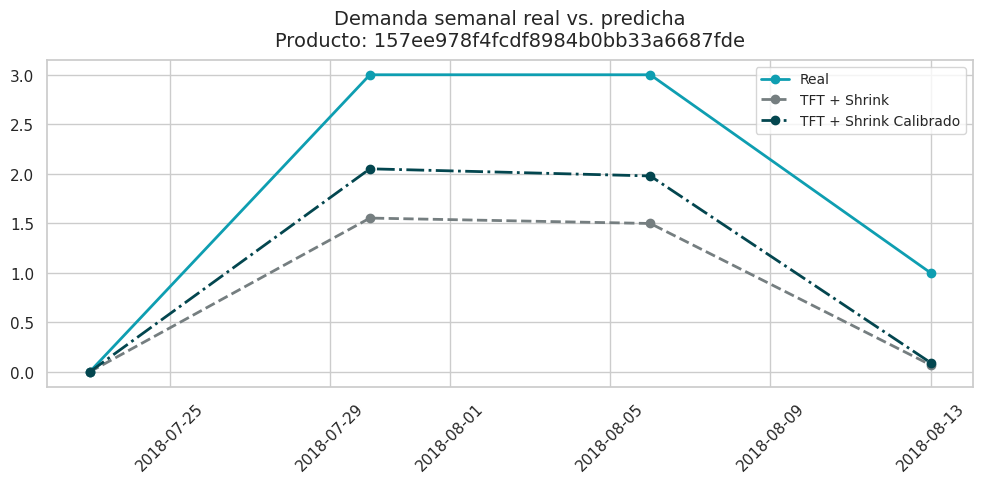

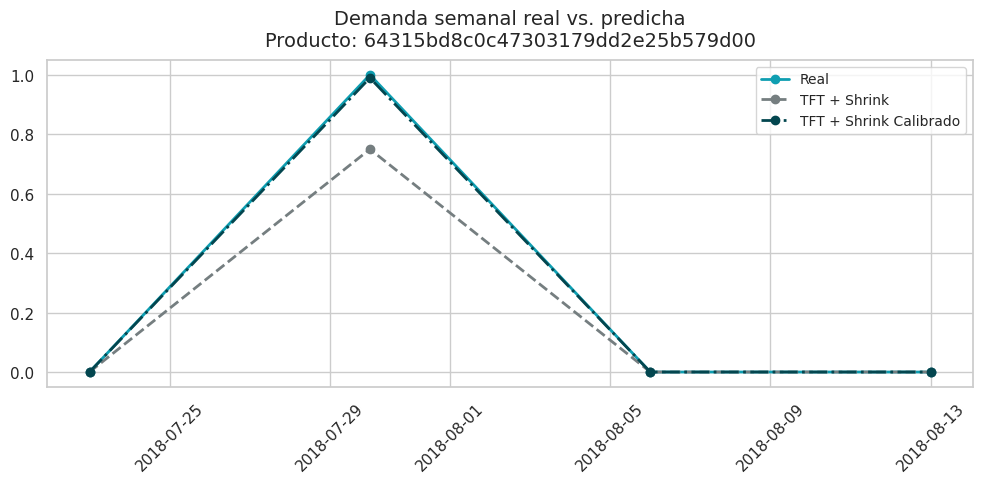

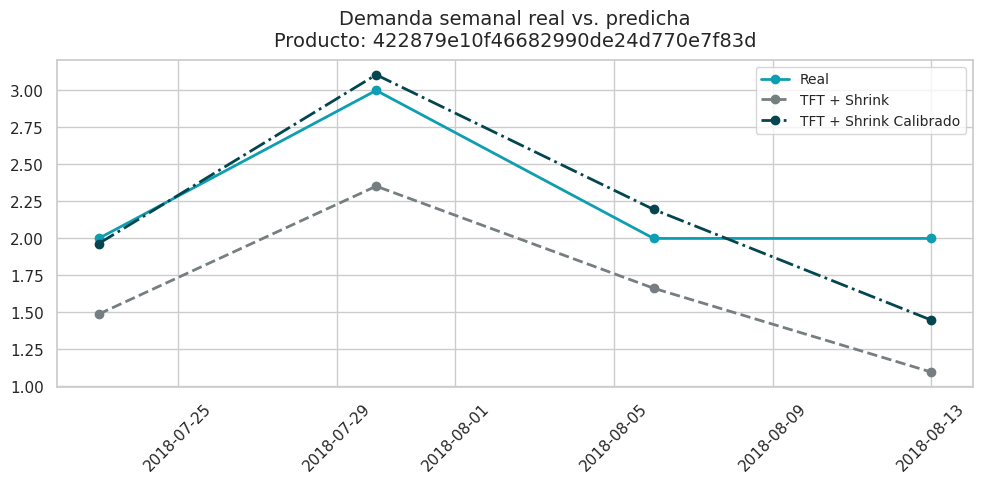

In [ ]:
# Seleccionar estilo
sns.set_theme(style="whitegrid")

# Bucle sobre la muestra de productos elegida
for producto in muestra_productos:

    # Filtrar los datos para el producto específico
    df_plot = df_eval[df_eval['unique_id'] == producto].copy()

    # Red de seguridad: si el producto no está en la muestra, se salta al siguiente
    if df_plot.empty:
        print(f"Sin datos de evaluación para el producto: {producto}")
        continue

    # Ordenar datos cronológicamente
    df_plot = df_plot.sort_values('ds')

    # Crear la figura
    plt.figure(figsize=(10, 5))

    # Dibujar las series temporales
    plt.plot(
        df_plot['ds'],
        df_plot['y'],
        marker='o',
        color='#0E9EB1',
        label='Real',
        linewidth=2,
        markersize=6
    )

    plt.plot(
        df_plot['ds'],
        df_plot['TFT_Final/MinTrace_method-mint_shrink'],
        marker='o',
        color='#757e80',
        linestyle='--',
        label='TFT + Shrink',
        linewidth=2
    )

    plt.plot(
        df_plot['ds'],
        df_plot['TFT_Calibrado'],
        marker='o',
        color='#03464f',
        linestyle='-.',
        label='TFT + Shrink Calibrado',
        linewidth=2
    )

    # Configurar formato
    plt.title(f'Demanda semanal real vs. predicha\nProducto: {producto}', fontsize=14, pad=10)
    plt.xlabel('', fontsize=12)
    plt.ylabel('', fontsize=12)
    plt.legend(fontsize=10, loc='best')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Mostrar el gráfico
    plt.show()

In [ ]:
# Filtrar dataframe por la muestra de productos
df_eval_filtrado = df_eval[df_eval['unique_id'].isin(muestra_productos)]

# Imprimir dataframe
# display(df_eval_filtrado)

In [ ]:
# Descargar dataframe
df_eval_filtrado.to_csv(os.path.join(ruta_output, 'df_eval_filtrado.csv'), index=False, sep=';', decimal=',')

### **8.2. Serie diaria**

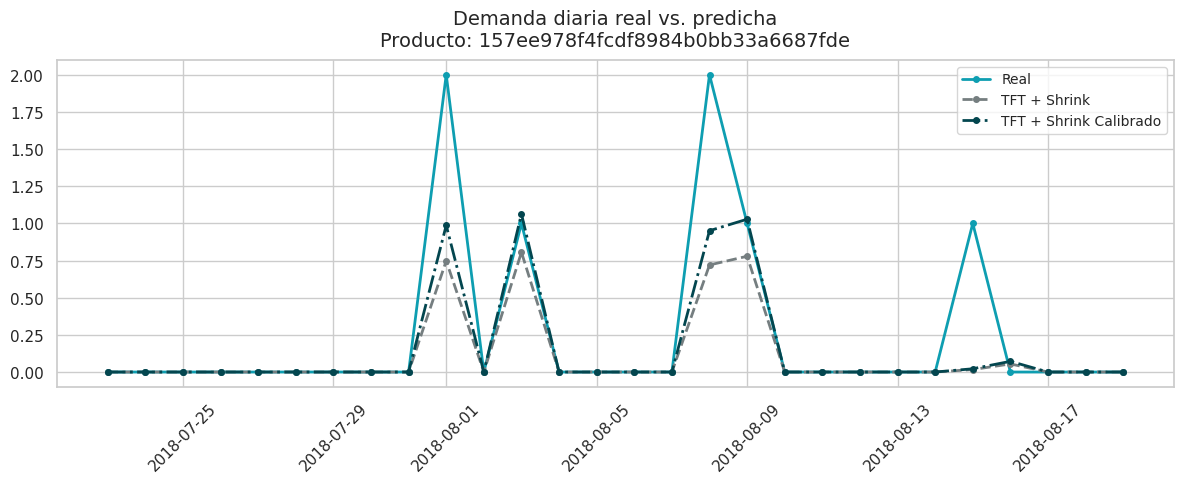

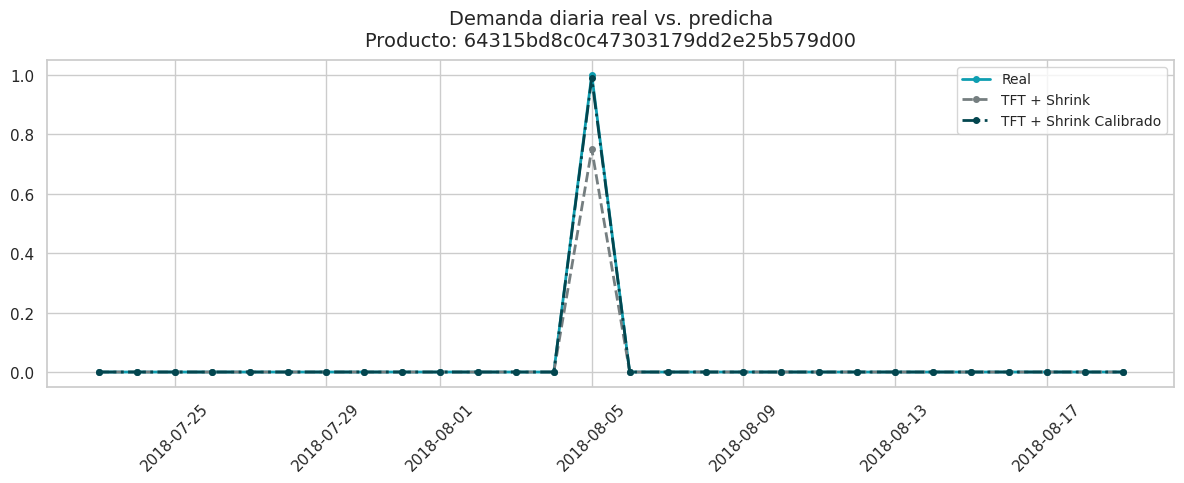

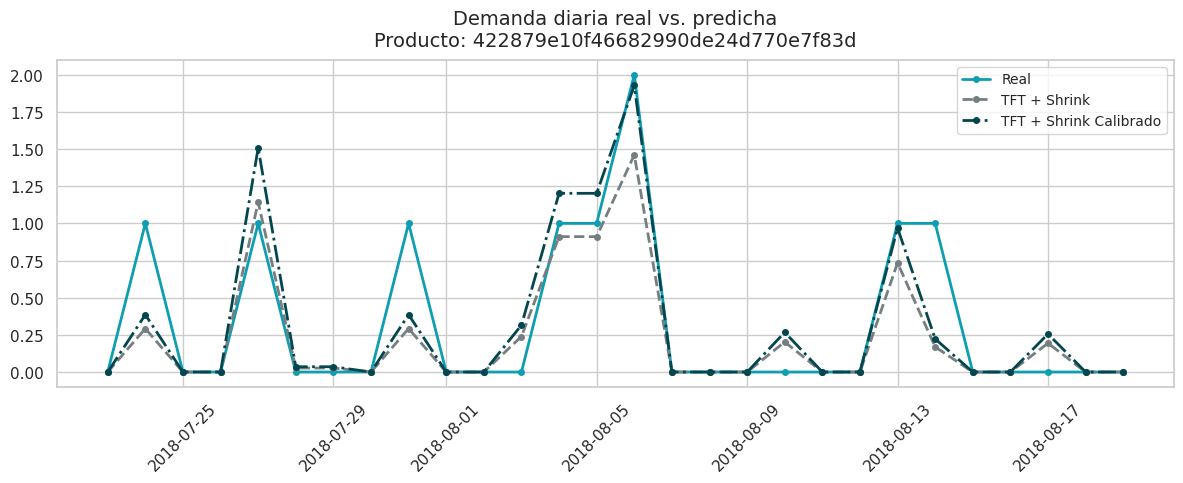

In [ ]:
# Configurar el estilo
sns.set_theme(style="whitegrid")

# Bucle sobre la muestra de productos elegida
for producto in muestra_productos:

    # Filtrar los datos para el producto específico
    df_plot = df_eval_diario[df_eval_diario['unique_id'] == producto].copy()

    # Red de seguridad: si el producto no está en la muestra, se salta al siguiente
    if df_plot.empty:
        print(f"Sin datos de evaluación para el producto: {producto}")
        continue

    # Ordenar datos cronológicamente
    df_plot = df_plot.sort_values('ds')

    # Crear la figura
    plt.figure(figsize=(12, 5))

    # Dibujar las series temporales
    plt.plot(
        df_plot['ds'],
        df_plot['y'],
        marker='o',
        color='#0E9EB1',
        label='Real',
        linewidth=2,
        markersize=4
    )

    plt.plot(
        df_plot['ds'],
        df_plot['TFT_Final/MinTrace_method-mint_shrink'],
        marker='o',
        color='#757e80',
        linestyle='--',
        label='TFT + Shrink',
        linewidth=2,
        markersize=4
    )

    plt.plot(
        df_plot['ds'],
        df_plot['TFT_Calibrado'],
        marker='o',
        color='#03464f',
        linestyle='-.',
        label='TFT + Shrink Calibrado',
        linewidth=2,
        markersize=4
    )

    # Configurar formato
    plt.title(f'Demanda diaria real vs. predicha\nProducto: {producto}', fontsize=14, pad=10)
    plt.xlabel('', fontsize=12)
    plt.ylabel('', fontsize=12)
    plt.legend(fontsize=10, loc='best')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Mostrar el gráfico
    plt.show()

In [ ]:
# Filtrar dataframe por la muestra de productos
df_eval_diario_filtrado = df_eval_diario[df_eval_diario['unique_id'].isin(muestra_productos)]

# Imprimir dataframe
# display(df_eval_diario_filtrado)

In [ ]:
# Descargar dataframe
df_eval_diario_filtrado.to_csv(os.path.join(ruta_output, 'df_eval_diario_filtrado.csv'), index=False, sep=';', decimal=',')